In [1]:
import numpy as np
import pandas as pd
import glob, os, warnings, shutil, subprocess, re, sys
from Bio import Seq, SeqIO
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
import scipy
from matplotlib.ticker import ScalarFormatter
import lifelines
from datetime import datetime
from matplotlib.patches import Patch

sys.path.append("scripts")
from variant_analysis_utils import *
# from epi_utils import *

h37Rv_path = "./H37Rv"
h37Rv_seq = SeqIO.read(os.path.join(h37Rv_path, "GCF_000195955.2_ASM19595v2_genomic.gbff"), "genbank")
h37Rv_genes = pd.read_csv(os.path.join(h37Rv_path, "mycobrowser_h37rv_genes_v4.csv"))

h37Rv_regions = pd.read_csv(os.path.join(h37Rv_path, "mycobrowser_h37rv_v4.csv"))

# these are promoters, transcriptional signals, or RNAs. Exclude these
non_coding_regions = h37Rv_regions.query("Feature != 'CDS'").Name.values

# if these remain in the dataframe, then there will be multiple entires for a single gene name, which will cause process_intergenic_variant_WHO_catalog_coord to fail
h37Rv_regions = h37Rv_regions.query("~Feature.str.contains('|'.join(['promoter', 'signal']), case=False)")
assert len(h37Rv_regions) == h37Rv_regions.Name.nunique()

h37Rv_coords = pd.read_csv(os.path.join(h37Rv_path, "h37Rv_coords_to_gene.csv.gz"), compression='gzip')
h37Rv_coords_dict = dict(zip(h37Rv_coords["pos"].values, h37Rv_coords["region"].values))

# isolates with matched LR sequencing (including samples from the same patient where only 1 sample had LR done)
isolates_with_LR = pd.read_csv("./data/TRUST_isolates_long_read_aln.tsv", sep='\t', header=None)

TRUST_data_dir = "/home/sak0914/TRUST_data_processing/processed_data"
CNN_results_dir = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results"

silent_lst = ['initiator_codon_variant', 'synonymous_variant', 'stop_retained_variant']

out_dir = "/n/data1/hms/dbmi/farhat/Sanjana/TRUST_lowAF"
F2_thresh = 0.03

df_WGS = pd.read_csv(f"{TRUST_data_dir}/20250818_combined_patient_WGS_data.csv")
df_WGS.SampleID.nunique()

880248 runs of at least 2
730854 nucleotides are in homopolymeric tracts


In [2]:
from epi_utils import *

# Variants Present in ≥N% of Isolates

https://pmc.ncbi.nlm.nih.gov/articles/PMC11459938/

This paper did in vitro selection using artemisinin, an antimaliarial. They found mutations in glpK (multiple frameshifts in the homopolymeric tract) and glpQ1 (1 frameshift = 4315194	ATC>AC)

# Get Genome-Wide Phase Variants and Matrices for Samples 1 and 2 for each pid

In [3]:
df_longitudinal_pids = pd.read_csv(f"./data/longitudinal_pids_WGS_data.csv")
print(f"{df_longitudinal_pids.pid.nunique()} pids")

HT_regions = pd.read_csv("./data/nucleotide_runs_all_lengths.csv")
print(f"{len(HT_regions)} runs of at least 2")

HT_nucs = []

for i, row in HT_regions.query("Length >= 3").iterrows():
    # don't need to add 1 to the end because the start is one of the N nucleotides
    # BUT add 1 bp to the front and back so that you include variants that occur adjacent to an HT region, not just within it
    HT_nucs += list(np.arange(row['POS'] - 1, row['POS'] - 1 + row['Length'] + 1))

HT_nucs = np.unique(HT_nucs)
print(f"{len(HT_nucs)} nucleotides are in homopolymeric tracts")

299 pids
880248 runs of at least 2
730854 nucleotides are in homopolymeric tracts


In [4]:
pids_with_low_F2 = pd.DataFrame(df_longitudinal_pids.query("F2 <= @F2_thresh").groupby('pid')['SampleID'].nunique()).query("SampleID > 1").index.values

print(f"{len(pids_with_low_F2)}/{df_longitudinal_pids.pid.nunique()} pids have F2 ≤ {F2_thresh} for both samples")

# additionally require pids to have had the EXACT same lineage
pids_with_same_lineage = pd.DataFrame(df_longitudinal_pids.query("pid in @pids_with_low_F2").groupby('pid')['Coll2014'].nunique()).query("Coll2014 == 1").index.values
pids_with_same_lineage = pd.DataFrame(df_longitudinal_pids.query("pid in @pids_with_same_lineage").groupby('pid')['Freschi2020'].nunique()).query("Freschi2020 == 1").index.values

print(f"{len(pids_with_same_lineage)}/{len(pids_with_low_F2)} pids have the same Coll2014 lineages")

df_variants, sample_1_variants, sample_2_variants = get_matrix_of_phase_variant_indels("./results/genome", 
                                                                                      df_longitudinal_pids.query("pid in @pids_with_same_lineage"), # exclude pids with mixed samples 
                                                                                      HT_nucs, 
                                                                                      sample_2=True, 
                                                                                      binarize_fixed_variants=False, 
                                                                                      fixed_thresh=0.95, 
                                                                                      absent_thresh=0.05
                                                                                     )

# subtract to get a difference matrix
indels_difference = sample_2_variants - sample_1_variants

279/299 pids have F2 ≤ 0.03 for both samples
271/279 pids have the same Coll2014 lineages
271 samples with 297 variants


In [5]:
sample_dir = "./results/genome"

df_variants_all = pd.concat([pd.read_csv(f"{sample_dir}/fixed_variants.csv"), pd.read_csv(f"{sample_dir}/unfixed_variants.csv")])

# Combine Phase Variants in the Same Gene into a single Variable for the Gene

In [6]:
sample_1_variants, genes_with_frameshifts = combine_frameshifts_single_gene(sample_1_variants, difference=False)
sample_2_variants, _ = combine_frameshifts_single_gene(sample_2_variants, difference=False)
indels_difference, _ = combine_frameshifts_single_gene(indels_difference, difference=True)

Collapsed 297 variants into 276
Collapsed 297 variants into 276
Collapsed 297 variants into 276


In [7]:
# get a list of variants to plot. Only plot variants with a change in at least freq_thresh pids
freq_thresh = 1
variants_with_change_thresh = []

for col in indels_difference.columns:
    if len(indels_difference.loc[indels_difference[col].abs() >= 0.1]) >= freq_thresh:
        variants_with_change_thresh.append(col)

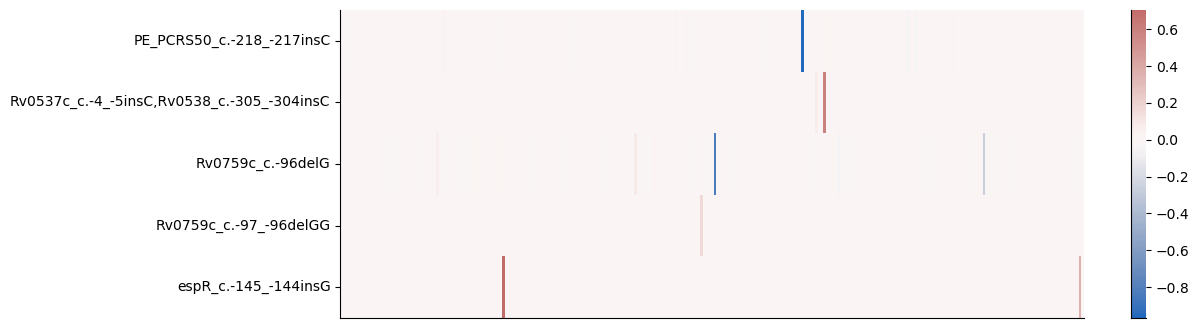

In [9]:
fig, ax = plt.subplots(figsize=(12, 4))

noncoding_change_variants = np.sort(list(set(indels_difference.columns[~indels_difference.columns.isin(genes_with_frameshifts)]).intersection(variants_with_change_thresh)))

sns.heatmap(indels_difference[noncoding_change_variants].T,
            center=0,
            cmap=sns.color_palette("vlag", as_cmap=True),
            ax=ax,
            xticklabels=False,
           )

sns.despine()
# plt.title(f"Change in Allele Fraction between First and Second WGS Samples in Non-Coding Homopolymeric Tracts in {indels_difference.shape[0]} pids")
plt.savefig("./results/figures/longitudinal_changes_noncoding_regions.svg", bbox_inches='tight')

In [67]:
var = 'espR_c.-145_-144insG'

indels_difference.loc[(indels_difference[var] >= 0.05) | (indels_difference[var] <= -0.05)][var]

T0090    0.704484
T0475    0.353561
Name: espR_c.-145_-144insG, dtype: float64

In [68]:
df_WGS.query("pid in ['T0090', 'T0475']")[['pid', 'F2', 'Coll2014', 'bl_household', 'bl_housecode', 'bl_houseclose', 'bl_houseclosenum',
       'bl_houseclose_1code', 'bl_houseclose_1type', 'bl_houseclose_2code',
       'bl_houseclose_2type']]

,pid,F2,Coll2014,bl_household,bl_housecode,bl_houseclose,bl_houseclosenum,bl_houseclose_1code,bl_houseclose_1type,bl_houseclose_2code,bl_houseclose_2type
284,T0475,0.011800,2.2.1.1,0,NaN,0,NaN,NaN,NaN,NaN,NaN
285,T0475,0.010622,2.2.1.1,0,NaN,0,NaN,NaN,NaN,NaN,NaN
462,T0090,0.010696,2.2.1.1,0,NaN,1,1.0,SP4,1.0,NaN,NaN
463,T0090,0.011483,2.2.1.1,0,NaN,1,1.0,SP4,1.0,NaN,NaN


In [86]:
df_WGS.columns[df_WGS.columns.str.contains('bl_house')]

Index(['bl_household', 'bl_housecode', 'bl_houseclose', 'bl_houseclosenum',
       'bl_houseclose_1code', 'bl_houseclose_1type', 'bl_houseclose_2code',
       'bl_houseclose_2type'],
      dtype='object')

In [84]:
df_trust_patients.query("pid in ['T0090', 'T0475']")

,pid,Original_ID,SampleID,SampleLib,Pacbio,Comment,quality,Cov_Any_Mean,Cov_Unam_Perc,Perc_Reads_Mapped,...,RIF_AUC,INH_AUC,PZA_AUC,EMB_AUC,View,Outlier,predicted_PLI,predicted_Timika_Score,unique_patient,Date_of_Death
274,T0475,S0475-01,MFS-866,MFS-866_lib73362,NaN,NaN,1.0,478.76,0.99,0.9863,...,16.036,17.5810,264.44,17.581,NaN,NaN,NaN,NaN,136,NaN
275,T0475,S0475-06,MFS-867,MFS-867_lib73363,NaN,NaN,1.0,555.48,0.99,0.9847,...,16.036,17.5810,264.44,17.581,NaN,NaN,NaN,NaN,136,NaN
445,T0090,S0090-06,MFS-356,MFS-356_lib59080,NaN,NaN,1.0,376.28,0.99,0.9897,...,25.398,6.0251,183.90,12.683,1B,0.0,18.467005,24.31416,233,NaN
446,T0090,S0090-01,MFS-355,MFS-355_lib59079,NaN,NaN,1.0,308.78,0.99,0.9900,...,25.398,6.0251,183.90,12.683,1B,0.0,18.467005,24.31416,233,NaN


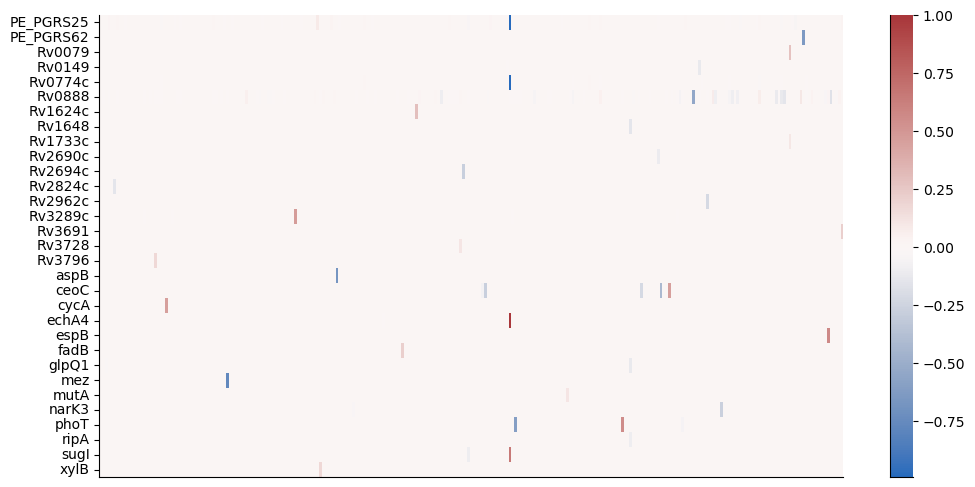

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))

coding_change_variants = np.sort(list(set(genes_with_frameshifts).intersection(variants_with_change_thresh)))

sns.heatmap(indels_difference[coding_change_variants].T,
            center=0,
            cmap=sns.color_palette("vlag", as_cmap=True),
            ax=ax,
            xticklabels=False,
           )

sns.despine()
# plt.title(f"Change in Allele Fraction between First and Second WGS Samples in Coding Homopolymeric Tracts in {indels_difference.shape[0]} pids")
plt.savefig("./results/figures/longitudinal_changes_coding_regions.svg", bbox_inches='tight')

In [14]:
np.abs(indels_difference).sum(axis=1).sort_values()

T0048    0.001779
T0054    0.001802
T0036    0.007287
T0341    0.008561
T0123    0.010274
           ...   
T0090    0.895571
T0470    0.925504
T0067    0.974402
T0277    1.165317
T0245    3.851439
Length: 271, dtype: float64

In [ ]:
df_longitudinal_pids.query("pid=='T0245'")

,pid,Original_ID,SampleID,Sampling_Week,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,F2,Lineage,Paired_Sample_Num,total_samples
320,T0245,245-01,MFS-156,1,2.2.1.1,2.2.1.1.1,"beijing,mungi","lin2.2.1,pacific_RD150",NaN,0.008521,2,1,2
321,T0245,245-08,MFS-157,8,2.2.1.1,2.2.1.1.1,"beijing,mungi","lin2.2.1,pacific_RD150",NaN,0.008931,2,2,2


# Combine Genes in the Same Pathway

In [11]:
# def combine_genes_of_similar_pathways(df, dict_of_lists_of_genes_to_group, difference=False):
#     '''
#     dict_of_lists_of_genes_to_group is a dictionary of lists of genes. Each element is name: list pair. The genes in each list need to combined together. 
#     '''
    
#     df_grouped_by_pathway = df.copy()
    
#     for pathway_name, genes_lst in dict_of_lists_of_genes_to_group.items():
        
#         for gene in genes_lst:
            
#             if difference:
#                 df_grouped_by_pathway[pathway_name] = df_grouped_by_pathway[genes_lst].mean(axis=1).fillna(0)

#             # do a sum because these dataframes are not measuring differences (so they can't be negative). 
#             else:
#                 # create a combined variable
#                 df_grouped_by_pathway[pathway_name] = df_grouped_by_pathway[genes_lst].max(axis=1)

#         # remove the component variables
#         df_grouped_by_pathway = df_grouped_by_pathway.drop(columns=genes_lst, axis=1)

#     print(f"Collapsed {df.shape[1]} variants into {df_grouped_by_pathway.shape[1]}")

#     return df_grouped_by_pathway

In [12]:
# # Mce-family proteins. Exclude mce1R because we don't know what the change in the transcription factor would do. Could be positive or negative, and since we're summing frameshifts, need everything to have hypothesized same direction
# # exclude mce2B because the annotation is suspect. According to mycobrowser, Rv0590A is a probable continuation of mce2B (Rv0590).
# # Possible nucleotide G missing at 688793 as there are 5 in Mycobacterium bovis but only 4 in CDC1551. 160/279 samples have this G missing, and the others don't. So might be a reference issue
# mammalian_cell_entry_genes = h37Rv_regions.query("Name in @genes_with_frameshifts & Product.str.contains('Mce-family')").Name.values
# mammalian_cell_entry_genes = list(set(mammalian_cell_entry_genes) - set(['mce1R', 'mce2B']))

# # esx genes. Exclude eccC2 because the frameshift is found in ~1/2 of samples? But it's a real variant
# esx_genes = h37Rv_regions.query("Name in @genes_with_frameshifts & Product.str.contains('esx', case=False)").Name.values
# esx_genes = list(set(esx_genes) - set(['eccC2']))

# # virulence_genes = h37Rv_regions.query("Name in @genes_with_frameshifts & (Functional_Category.str.contains('virulence', case=False) | (Product.str.contains('esx', case=False)) | Name.str.contains('mce'))")[['Name', 'Function', 'Product', 'Functional_Category', 'Comments']].Name.values

# # metabolism_genes = h37Rv_regions.query("Name in @genes_with_frameshifts & Name not in @virulence_genes & Functional_Category.str.contains('metabolism', case=False)").Name.values
# lipid_metabolism_genes = h37Rv_regions.query("Name in @genes_with_frameshifts & Functional_Category=='lipid metabolism'").Name.values

# other_metabolism_genes = h37Rv_regions.query("Name in @genes_with_frameshifts & Name not in @lipid_metabolism_genes & Functional_Category.str.contains('metabolism', case=False)").Name.values

# # metabolism_genes = h37Rv_regions.query("Name in @genes_with_frameshifts & Name not in @virulence_genes & Functional_Category.str.contains('metabolism', case=False)").Name.values
# transcription_factors = h37Rv_regions.dropna(subset='Function').query("Name in @genes_with_frameshifts & Function.str.contains('transcription')").Name.values

# gene_grouping_dict = {'mammalian_cell_entry': mammalian_cell_entry_genes, 'esx': esx_genes, 'lipid_metabolism': lipid_metabolism_genes, 'other_metabolism': other_metabolism_genes, 'transcription_factors': transcription_factors}


In [13]:
# sample_1_variants_grouped_pathways = combine_genes_of_similar_pathways(sample_1_variants, gene_grouping_dict, difference=False)
# sample_2_variants_grouped_pathways = combine_genes_of_similar_pathways(sample_2_variants, gene_grouping_dict, difference=False)
# indels_difference_grouped_pathways = combine_genes_of_similar_pathways(indels_difference, gene_grouping_dict, difference=True)

In [14]:
# df_check = sample_1_variants.drop(high_F2_pids.pid.unique(), axis=0)

# for col in esx_genes:
#     print(col, len(df_check.loc[(df_check[col] >= 0.05) & (df_check[col] <= 0.75)]))

In [15]:
# for col in list(gene_grouping_dict.keys()):
    
#     print(col, len(sample_1_variants_grouped_pathways.loc[sample_1_variants_grouped_pathways[col] != 0]), len(sample_1_variants_grouped_pathways))

# Cox Models

In [35]:
# freebayes_VCFs = []
# freebayes_samples = []

# for sample in df_WGS.dropna(subset='Lineage').SampleID.values:
    
#     fName = f"/n/data1/hms/dbmi/farhat/Sanjana/TRUST_lowAF/{sample}/freebayes/{sample}.SNPs.vcf"
    
#     assert os.path.isfile(fName)
    
#     freebayes_VCFs.append(fName)
#     freebayes_samples.append(sample)
    
# print(len(freebayes_VCFs))

# pd.Series(freebayes_VCFs).to_csv("./data/freebayes_VCF_fNames.txt", sep='\t', header=None, index=False)

In [36]:
df_trust_patients = pd.read_csv(f"{TRUST_data_dir}/20250827_cleaned_patient_outcomes_data.csv").dropna(subset='Lineage')

# fix lineages. Sometimes the names got converted to integers for the single number lineages
for i, row in df_trust_patients.iterrows():
    if not pd.isnull(row['Lineage']):
        if type(row['Lineage']) != str:
            df_trust_patients.loc[i, 'Lineage'] = str(int(row['Lineage']))

df_trust_patients['Lineage'] = df_trust_patients['Lineage'].astype(str)
df_trust_patients['Lineage'] = df_trust_patients['Lineage'].replace('nan', np.nan)

df_trust_patients['Lineage'].value_counts()

Lineage
2      363
4      317
3       49
2,4      6
1        1
2,3      1
Name: count, dtype: int64

# TCC

In [37]:
def add_change_to_indel_to_patient_data(df, sample_1_variants, sample_2_variants, indels_difference, variant, freq_thresh=3, include_interaction=True):

    num_samples_with_indel_change = len(indels_difference.loc[(indels_difference[variant] > 0.1) | (indels_difference[variant] < -0.1)])
    
    num_samples_variant_initial = sample_1_variants[variant].sum()
    num_samples_variant_final = sample_2_variants[variant].sum()

    # if num_samples_variant_initial < freq_thresh and num_samples_variant_final < freq_thresh:
    #     print(f"    Fewer than {freq_thresh} patients have {variant} at the beginning and end. Skipping this variant...")
    #     return None
    
    if num_samples_with_indel_change < freq_thresh:
        print(f"    Only {num_samples_with_indel_change} patients have a change in {variant}. Skipping this case...")
        return None

    # add the indel to the dataframe. Change the name of the column because the format like _p. can mess with the string encoding the formula in the Cox model
    df_with_variant = df.merge(indels_difference[[variant]], left_on='pid', right_index=True).rename(columns={variant: 'Indel_Change'})

    # also add an AF variable for whether the variable was present at baseline
    df_with_variant = df_with_variant.merge(sample_1_variants[[variant]], left_on='pid', right_index=True).rename(columns={variant: 'Indel_Sample1'})

    # include interaction between the two
    if include_interaction:
        df_with_variant['Indel_Sample1_x_Change'] = df_with_variant['Indel_Sample1'] * df_with_variant['Indel_Change']

    return df_with_variant

# Build a patient data model using all relevant patient predictors

## First determine the model form by checking the proportional hazards assumption

In [85]:
cols_lst = [
            'screen_sex',
            'screen_years',
            'underweight',
            'fstrom1_baseline', # smoking yes or no
            'smoked_substance_use',
            'peth_value_baseline',
            'HIV_CD4',
            'bl_prevtb',
            'TTP_baseline',
            'smear_pos_no_contam_sputum_specimen_1', # binary variable for smear positivity at baseline
            'diabetes',
            'high_lung_involvement',
            'Lineage' # Lineage_3 is so rare and causes instabilities / needs to be stratified by
           ]


# try these first, as they were required for the full TCC model
stratify_covariates = ['smear_pos_no_contam_sputum_specimen_1', 'HIV_CD4', 'high_lung_involvement']

non_linear_term_variables = []

df_trust_patients = pd.read_csv(f"{TRUST_data_dir}/20250827_cleaned_patient_outcomes_data.csv").dropna(subset='Lineage')

df_imputed_TCC = pd.read_csv(f"{TRUST_data_dir}/imputed_TCC.csv").query("pid in @df_trust_patients.pid")

df_trust_patients = pd.read_csv(f"{TRUST_data_dir}/20250827_cleaned_patient_outcomes_data.csv").dropna(subset='Lineage')

df_imputed_TCC = pd.read_csv(f"{TRUST_data_dir}/imputed_TCC.csv").query("pid in @df_trust_patients.pid")

# use the lineage information from TRUST_lowAF, whereas 20250825_cleaned_patient_outcomes_data contains data from Illumina_culture_WGS_processed 
df_pids_for_outcomes_model = df_trust_patients.sort_values("Sampling_Week").drop_duplicates(subset='pid', keep='first')

del_cols = ['F2', 'Lineage', 'Coll2014', 'Freschi2020']

for col in del_cols:
    if col in df_pids_for_outcomes_model.columns:
        del df_pids_for_outcomes_model[col]
        
df_pids_for_outcomes_model = df_pids_for_outcomes_model.merge(df_longitudinal_pids, on=['pid', 'Original_ID', 'SampleID', 'Sampling_Week'])
        
df_pids_for_outcomes_model, TRUST_phenos, df_pred_combined = read_combine_all_TRUST_data(df_pids_for_outcomes_model, 
                                                                                         {'RIF': 'lineage_amino_acid',
                                                                                          'INH': 'lineage_amino_acid',
                                                                                          'EMB': 'lineage_amino_acid',
                                                                                          'PZA': 'amino_acid'}, 
                                                                                         CNN_results_dir,
                                                                                         F2_thresh=1, 
                                                                                         baseline_only=True
                                                                                        )

df_pids_for_outcomes_model['inh_resistant'] = (df_pids_for_outcomes_model['pid'].isin(TRUST_phenos.query("INH_lower_bound >= 0.1").pid.values)).astype(int)

df_pids_for_outcomes_model['underweight'] = (df_pids_for_outcomes_model['bl_bmi'] < 18).astype(int)

len(df_pids_for_outcomes_model), df_pids_for_outcomes_model.pid.nunique()

299 patients with uncontaminated WGS samples
299 patients with uncontaminated WGS samples taken in the first 2 weeks

0 patients: [] have multiple sequences at the same timepoint
Removing 0 patients: [] because there are multiple WGS samples at the same timepoint with different lineages
298 patients have MICs for RIF
298 patients have MICs for INH
298 patients have MICs for EMB
214 patients have MICs for PZA
298 patients have measured MICs in the first 2 weeks

Found predicted RIF MICs for 299 pids
Found predicted INH MICs for 299 pids
Found predicted EMB MICs for 299 pids
Found predicted PZA MICs for 299 pids
299 patients have predicted MICs


(299, 299)

In [87]:
df_test_results, df_samples_imputations, cph_models_imputations = fit_cox_models_all_imputations(df_pids_for_outcomes_model,
                                                                                                  df_pred_combined,
                                                                                                   TRUST_phenos,
                                                                                                  df_imputed_TCC,
                                                                                                  cols_lst,
                                                                                                  event_col = 'culture_convert',
                                                                                                  time_col = 'TCC',
                                                                                                 MIC_type = 'none',
                                                                                                 include_drugs = ['INH'],
                                                                                                  invert_OR=True,
                                                                                                  stratify_variables=stratify_covariates,
                                                                                                 binary_lineage=True
                                                                                                 )

df_violating_covariates = []

for model_idx in range(len(cph_models_imputations)):

    df_proportional_hazards = lifelines.statistics.proportional_hazard_test(cph_models_imputations[model_idx], df_samples_imputations[model_idx], time_transform='rank').summary

    # diabetes has a p-value of like 0.0105
    violating_covariates = df_proportional_hazards.reset_index()[['index', 'p']].rename(columns={'index': 'covariate'})
    
    violating_covariates['imp_num'] = model_idx + 1

    df_violating_covariates.append(violating_covariates)

df_violating_covariates = pd.concat(df_violating_covariates)

# convert to HR per 10 years
OR_col = 'HR_TCC_assoc'
df_test_results.loc[df_test_results['covariate']=='screen_years', [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']] = df_test_results.loc[df_test_results['covariate']=='screen_years', [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']]**10

    283 total pids


In [92]:
df_violating_covariates.query("p <= 0.01").covariate.value_counts()#.drop_duplicates('covariate')

Series([], Name: count, dtype: int64)

In [89]:
df_violating_covariates.covariate.unique()

array(['Lineage_2', 'TTP_baseline', 'bl_prevtb', 'diabetes',
       'fstrom1_baseline', 'peth_value_baseline', 'screen_sex',
       'screen_years', 'smoked_substance_use', 'underweight'],
      dtype=object)

In [93]:
label_dict = {'INH_AUC': 'Isoniazid Exposure',
              'INH_midpoint': 'Measured INH MIC (µg/mL)',
              'Lineage_2': 'Lineage 2',
              'TTP_baseline': 'Time to Culture Positivity',
              'bl_bmi': 'Body Mass Index',
              'underweight': 'BMI < 18',
              'bl_prevtb': 'Previous TB Disease',
              'diabetes': 'Diabetes',
              'fstrom1_baseline': 'Smoking',
              'inh_resistant': 'Isoniazid Resistant',
              'screen_sex': 'Male Sex',
              'screen_years': 'Age',
              'smoked_substance_use': 'Smoked Substance Use',
              'peth_value_baseline': 'PEth Value'
             }

forest_plot(df_test_results, 
            df_test_results.sort_values("pval", ascending=True).covariate.values,
            # ['screen_sex', 'screen_years', 'bl_bmi', 'fstrom1_baseline', 'diabetes', 'bl_prevtb', 'inh_resistant', 'INH_AUC', 'TTP_baseline', 'Lineage_2'],
            label_dict, 
            val_col='HR_TCC_assoc', 
            alpha=0.05, 
            log=False, 
            pval_offset=1.05, 
            df_stratify_variables_results=None, 
            saveName="./results/figures/TCC/base_model_lowF2.svg"
           )

# KM Estimate

In [146]:
TCC_pids = df_samples_imputations[0].pid.values

df_cultures = pd.read_csv(f"{TRUST_data_dir}/cultures.csv").query("pid in @TCC_pids")

df_imputed_TCC = pd.read_csv(f"{TRUST_data_dir}/imputed_TCC.csv").query("pid in @TCC_pids")

df_TCC = pd.read_csv(os.path.join(TRUST_data_dir, "TCC.csv")).query("pid in @TCC_pids")

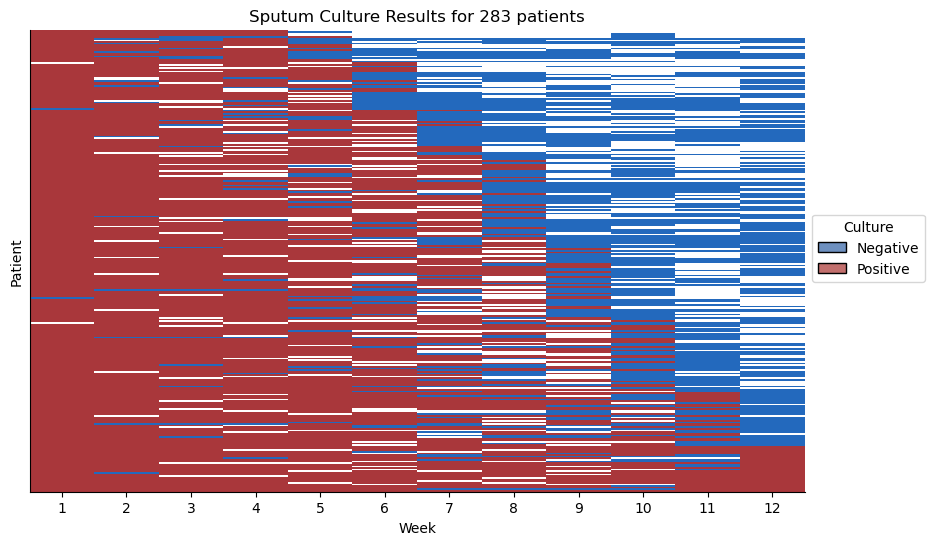

In [147]:
cultures_for_heatmap = df_cultures.query("sample_num <= 12").pivot(index='pid', columns='sample_num', values='result')

# same thing done before computing TCC and running imputation
cultures_for_heatmap = cultures_for_heatmap.replace('tb_positive_contaminated', 'tb_positive').replace('tb_negative_contaminated', np.nan).replace('tb_positive', 1).replace('tb_negative', 0)
cultures_for_heatmap.shape

fig, ax = plt.subplots(figsize=(10, 6))

# sort the patients by the number of positive cultures they have, increasing
# sort_lst = pd.DataFrame(cultures_for_heatmap.sum(axis=1)).sort_values(0).index.values

sort_lst = df_imputed_TCC.query("imp_num==0").sort_values(['TCC'], ascending=[True])['pid'].values

cultures_for_heatmap = cultures_for_heatmap.loc[sort_lst]

sns.heatmap(cultures_for_heatmap, cmap='vlag', cbar=False)

ax.set_yticks([])

plt.ylabel('Patient')
plt.xlabel('Week')

# Create a custom legend
legend_elements = [
    Patch(facecolor=sns.color_palette("vlag").as_hex()[0], edgecolor='black', label='Negative'),
    Patch(facecolor=sns.color_palette("vlag").as_hex()[-1], edgecolor='black', label='Positive')
]

ax.legend(
    handles=legend_elements, 
    title='Culture', 
    loc='upper left', 
    bbox_to_anchor=(1.01, 0.6),  # Adjust the position
    borderaxespad=0
)

plt.title(f"Sputum Culture Results for {cultures_for_heatmap.index.nunique()} patients")
sns.despine()
plt.savefig("./results/figures/TCC/sputum_heatmap.svg", bbox_inches='tight')

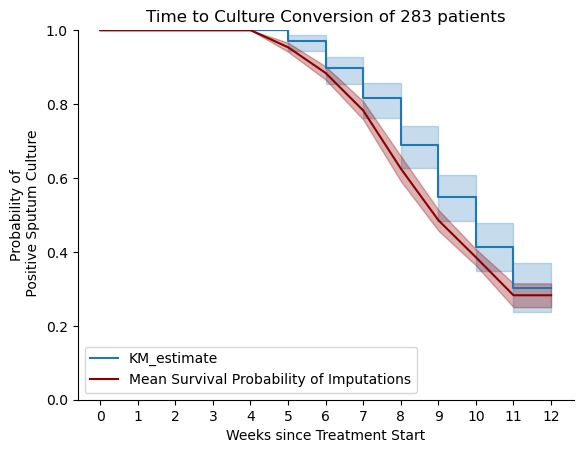

In [148]:
median_survival_imputations = {}

# Prepare a list to collect survival functions from each imputation
survival_curves = []

# Fit Kaplan-Meier for each imputation and store survival function
for imp in df_imputed_TCC['imp_num'].unique():
    imputed_data = df_imputed_TCC.query("imp_num==@imp")

    kmf = lifelines.KaplanMeierFitter()
    kmf.fit(durations=imputed_data['TCC'], event_observed=imputed_data['culture_convert'])
    
    survival_curves.append(kmf.survival_function_.rename(columns={"KM_estimate": f"imp_{imp}"}))
    
    median_survival_imputations[imp] = kmf.median_survival_time_

# Combine all imputed survival functions into one DataFrame
df_survival = pd.concat(survival_curves, axis=1)


kmf_full_dataset = lifelines.KaplanMeierFitter()
kmf_full_dataset.fit(df_TCC['TCC'], event_observed=df_TCC['culture_convert'])

fig, ax = plt.subplots()

kmf_full_dataset.plot_survival_function()#show_censors=True, censor_styles={"marker": "+", "ms": 8, "mew": 0.5})
plt.ylim(0, 1)

# Set x-axis ticks to show all integers
ax.set_xticks(range(0, df_imputed_TCC.TCC.max() + 1))

mean_survival = df_survival.mean(axis=1)
sd_survival = df_survival.std(axis=1)

# plot the mean survival probability at each week across the imputations
# plt.step(df_survival.index, mean_survival, label='KM Estimate of Imputed Datasets', where='post')
plt.plot(df_survival.index, mean_survival, label='Mean Survival Probability of Imputations', color='darkred')#, where='post')

# Calculate and plot the confidence interval using 1.96 * std for ~95% CI
ci_upper = mean_survival + 1.96 * sd_survival
ci_lower = mean_survival - 1.96 * sd_survival

# 'tab:blue'
plt.fill_between(df_survival.index, ci_lower, ci_upper, alpha=0.3, color='darkred')#, label='95% CI')

plt.title(f"Time to Culture Conversion of {df_imputed_TCC.pid.nunique()} patients")
plt.ylabel("Probability of\n Positive Sputum Culture") #
plt.xlabel("Weeks since Treatment Start")

plt.gca().get_legend().remove()
plt.legend()

sns.despine()
plt.savefig("./results/figures/TCC/KM_estimate.svg", bbox_inches='tight')

## Check that the association between TCC and the stratified variables make sense

Smear Positivity: χ^2 = 10.053779571887073, p = 0.0015203570166821504
HIV, CD4 Count: χ^2 = 2.1207596056830194, p = 0.34632425041383313
> 20% Lung Affected: χ^2 = 3.845635398751525, p = 0.04987562043038559


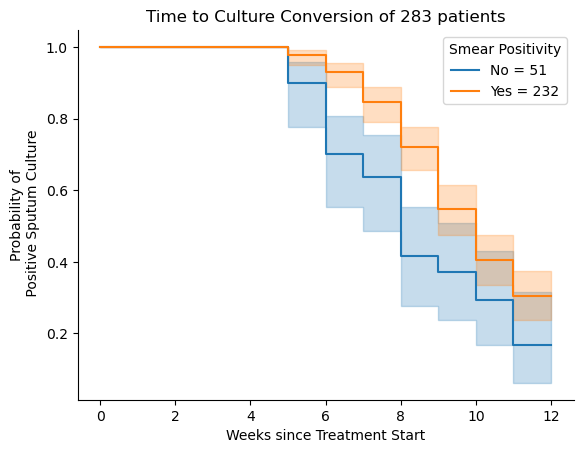

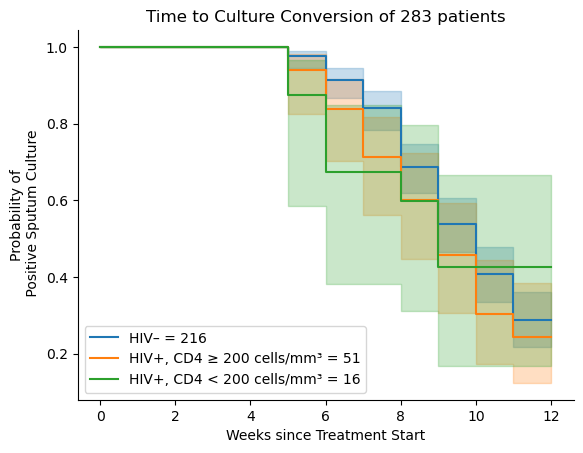

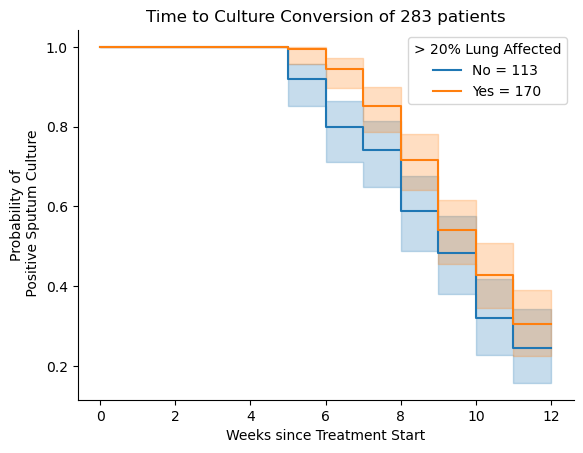

In [149]:
imp_num = 0
df_check_stratify_vars = df_pids_for_outcomes_model.merge(df_imputed_TCC.query("imp_num==@imp_num")[['pid', 'TCC', 'culture_convert']], on='pid')
df_check_stratify_vars['high_lung_involvement'] = (df_check_stratify_vars['predicted_PLI'] > 20).astype(int)
df_check_stratify_vars = df_check_stratify_vars.query("pid in @TCC_pids")

labels_dict = {'smear_pos_no_contam_sputum_specimen_1': 'Smear Positivity', 
               'high_lung_involvement': '> 20% Lung Affected', 
               'cxr_cavity_chest_radiograph_1': 'Cavitation',
               'HIV_CD4': 'HIV, CD4 Count',
               'screen_sex': 'Sex'
              }

color_dict = dict(zip([0, 1, 2], sns.color_palette().as_hex()))

HIV_CD4_dict = {0: 'HIV–', 1: 'HIV+, CD4 ≥ 200', 2: 'HIV+, CD4 < 200'}

for variable in stratify_covariates:

    fig, ax = plt.subplots()

    df_check_stratify_vars[variable] = df_check_stratify_vars[variable].astype(int)

    # sort so that 0 is plotted before 1
    for group in np.sort(df_check_stratify_vars[variable].unique()):
        
        if variable == 'HIV_CD4':
            legend_marker_dict = {0: 'HIV–', 1: 'HIV+, CD4 ≥ 200 cells/mm\u00B3', 2: 'HIV+, CD4 < 200 cells/mm\u00B3'}
            color_dict = dict(zip(np.arange(len(sns.color_palette().as_hex())), sns.color_palette().as_hex()))
        else:
            legend_marker_dict = {0: 'No', 1: 'Yes'}
            color_dict = dict(zip(np.arange(len(sns.color_palette().as_hex())), sns.color_palette().as_hex()))

        df_single_group = df_check_stratify_vars.query(f"{variable}==@group")
        kmf = lifelines.KaplanMeierFitter()
        kmf.fit(df_single_group['TCC'], event_observed=df_single_group['culture_convert'], label=group)
        kmf.plot_survival_function(ax=ax, show_censors=False, color=color_dict[group], censor_styles={"marker": "+", "ms": 8, "mew": 0.5}, label=f"{legend_marker_dict[group]} = {len(df_single_group)}")

        if variable == 'HIV_CD4':
            plt.legend(title='')
        else:
            plt.legend(title=labels_dict[variable])

    logRank_test_results = lifelines.statistics.multivariate_logrank_test(event_durations=df_check_stratify_vars['TCC'], 
                                                                          groups=df_check_stratify_vars[variable], 
                                                                          event_observed=df_check_stratify_vars['culture_convert'], 
                                                                         )

    print(f"{labels_dict[variable]}: χ^2 = {logRank_test_results.test_statistic}, p = {logRank_test_results.p_value}")

    plt.title(f"Time to Culture Conversion of {df_check_stratify_vars.pid.nunique()} patients")
    plt.ylabel("Probability of\n Positive Sputum Culture") #
    plt.xlabel("Weeks since Treatment Start")
    sns.despine()
    # plt.show()
    plt.savefig(f"./results/figures/TCC/KM_estimate_TCC_stratified_{labels_dict[variable].replace(' ', '_').replace(',', '').replace('>', '')}.svg", bbox_inches='tight')

# Run models with the phase variation indels

In [58]:
df_pids_for_outcomes_model.merge(TRUST_phenos, on='pid').pid.nunique()

298

In [61]:
df_pids_for_outcomes_model.merge(TRUST_phenos, on='pid').merge(indels_difference, left_on='pid', right_index=True).pid.nunique()

272

In [73]:
df_results_all_indels = []

# test only variants that have are fixed (AF > 0.95) in at least one sample at baseline. Don't include variants thare never fixed at baseline.
test_variants_lst = pd.DataFrame(sample_1_variants.max(axis=0)).reset_index().rename(columns={'index': 'variant', 0:'AF_max'}).query("AF_max > 0.95")['variant'].values

# remove these 4 and add
test_variants_lst = list(set(test_variants_lst) - set(['Rv0759c_c.-97_-96delGG', 'Rv0759c_c.-96delG', 'htrA_c.-38_-37insG', 'htrA_c.-38_-37insGG']))

print(f"Testing associations between TCC and {len(test_variants_lst)} phase variants")

for variant in ['espR_c.-145_-144insG']: #test_variants_lst:

    print(f"Testing {variant}")

    df_imputed_patient_data_single_variant = add_change_to_indel_to_patient_data(df_pids_for_outcomes_model, 
                                                                                     sample_1_variants,
                                                                              sample_2_variants,
                                                                              indels_difference,
                                                                                     variant,
                                                                                     freq_thresh=2,
                                                                                     )

    # will be None if there are not enough patients with the specified change in the indel
    if df_imputed_patient_data_single_variant is not None:
    
#         pids_with_change = indels_difference_grouped_pathways.loc[(indels_difference_grouped_pathways[variant] >= 0.1) | (indels_difference_grouped_pathways[variant] <= -0.1)].index.values
        
#         # only include the Indel_Change variable if is at least 1 patient in each even / no event group with an AF change. Otherwise, you get perfect separation
#         # of the groups, and the hazard ratio estimates will be huge and unreliable
#         if df_imputed_TCC.loc[df_imputed_TCC['imp_num']==0].query("pid in @pids_with_change")['culture_convert'].nunique() == 2:
#             predictors_lst = final_patient_predictors + ['inh_resistant', 'Lineage'] + ['Indel_Sample1', 'Indel_Change']
#         else:
#             predictors_lst = final_patient_predictors + ['inh_resistant', 'Lineage'] + ['Indel_Sample1']

        df_test_results_indel, _, _ = fit_cox_models_all_imputations(df_imputed_patient_data_single_variant,
                                                                      df_pred_combined, 
                                                                        TRUST_phenos,
                                                                      df_imputed_TCC,
                                                                     cols_lst + ['Indel_Change'],
                                                                      event_col = 'culture_convert',
                                                                      time_col = 'TCC',
                                                                      invert_OR=True,
                                                                     MIC_type = 'measured',
                                                                    include_drugs = ['INH'],
                                                                      stratify_variables=stratify_covariates,
                                                                     binary_lineage=True
                                                                     )

    
        df_test_results_indel['Indel'] = variant
    
        df_results_all_indels.append(df_test_results_indel)
        
# paired_variants_lst = [['Rv0759c_c.-96delG', 'Rv0759c_c.-97_-96delGG'],
#                        ['htrA_c.-38_-37insG', 'htrA_c.-38_-37insGG']
#                       ]

# for variants_lst in paired_variants_lst:
    
#     df_imputed_patient_data_single_variant = df_pids_for_outcomes_model.merge(sample_1_variants[variants_lst], left_on='pid', right_index=True)

#     # messes with the names (underscores, periods), so rename
#     df_imputed_patient_data_single_variant.rename(columns={variants_lst[0]: 'Indel_1', variants_lst[1]: 'Indel_2'}, inplace=True)

#     df_test_results_indel, _, _ = fit_cox_models_all_imputations(df_imputed_patient_data_single_variant,
#                                                                   df_pred_combined,
#                                                                    TRUST_phenos,
#                                                                   df_imputed_TCC,
#                                                                  cols_lst + ['Indel_1', 'Indel_2'],
#                                                                   event_col = 'culture_convert',
#                                                                   time_col = 'TCC',
#                                                                   invert_OR=True,
#                                                                   MIC_type = 'measured',
#                                                                 include_drugs = ['INH'],
#                                                                   stratify_variables=stratify_covariates,
#                                                                  binary_lineage=True
#                                                                  )
    
#     df_test_results_indel['Indel'] = variants_lst[0].split('_')[0]
#     df_results_all_indels.append(df_test_results_indel)
    
df_results_all_indels = pd.concat(df_results_all_indels)

# fName = "./results/TCC/indel_change_lowF2.csv"

# df_results_all_indels.to_csv(fName, index=False)
# df_results_all_indels = pd.read_csv(fName)

Testing associations between TCC and 228 phase variants
Testing espR_c.-145_-144insG
    262 total pids


In [74]:
# fName = "./results/TCC/indel_change_lowF2.csv"
# df_results_all_indels = pd.read_csv(fName)

In [78]:
df_results_all_indels.query("pval <= 0.05").drop_duplicates(subset='covariate')[['covariate', 'pval', 'HR_TCC_assoc_lower', 'HR_TCC_assoc_upper']]

,covariate,pval,HR_TCC_assoc_lower,HR_TCC_assoc_upper
4,TTP_baseline,0.000043,0.120823,0.465564
10,screen_years,0.001610,1.009887,1.042223


In [79]:
df_results_all_indels.covariate.unique()

array(['INH_AUC', 'INH_midpoint', 'Indel_Change', 'Lineage_2',
       'TTP_baseline', 'bl_bmi', 'bl_prevtb', 'diabetes',
       'fstrom1_baseline', 'screen_sex', 'screen_years'], dtype=object)

In [80]:
df_results_all_indels.query("pval <= 0.05 & covariate=='Indel_Change'")

,covariate,coef_pooled,V_w,V_b,V_t,se_pooled,riv,wald_stat,dof_old,lambda,dof_observed,dof_adj,pval,t_critical,coef_lower,coef_upper,HR_TCC_assoc,HR_TCC_assoc_lower,HR_TCC_assoc_upper,Indel


In [232]:
def plot_survival_curve_by_indel(df_patient_data, df_outcome, event_variable, duration_variable, variant, sample_1_variants, sample_2_variants, indels_difference, exclude_fixed_absent=False, change_thresh=0.05, fixed_thresh=0.75, freq_thresh=5, logrank_test_compare_groups=['Gain', 'Loss'], colors_dict = {'Gain': '#1f77b4', 'Loss': '#ff7f0e', 'Fixed': '#d62728', 'Absent': '#2ca02c'}, p=0, q=0, save=False):

    if 'imp_num' not in df_outcome.columns:
        df_outcome['imp_num'] = 0
                
    # df_imputed_patient_data_single_variant = add_change_to_indel_to_patient_data(df_patient_data, 
    #                                                                              sample_1_variants, 
    #                                                                              sample_2_variants, 
    #                                                                              indels_difference,
    #                                                                              variant, 
    #                                                                              freq_thresh=freq_thresh
    #                                                                             )
    
    df_imputed_patient_data_single_variant = add_indel_at_baseline_to_patient_data(df_patient_data, 
                                                                                 sample_1_variants, 
                                                                                 variant, 
                                                                                )

    if df_imputed_patient_data_single_variant is not None:

        # for variable in stratify_covariates:
        df_plot_outcome = df_outcome.query("imp_num==0").merge(df_imputed_patient_data_single_variant.loc[df_imputed_patient_data_single_variant['.imp']==0][['pid', 'Indel_Sample1', 'Indel_Change', 'Indel_Sample1_x_Change']])

        df_plot_outcome.loc[(df_plot_outcome['Indel_Sample1'] <= change_thresh), 'Group'] = 'Absent'
        df_plot_outcome.loc[(df_plot_outcome['Indel_Sample1'] > change_thresh) & (df_plot_outcome['Indel_Sample1'] <= fixed_thresh), 'Group'] = 'Unfixed'
        df_plot_outcome.loc[(df_plot_outcome['Indel_Sample1'] > fixed_thresh), 'Group'] = 'Fixed'
        
        # df_plot_outcome.loc[(df_plot_outcome['Indel_Sample1'] <= change_thresh) & (df_plot_outcome['Indel_Change'] <= change_thresh), 'Group'] = 'Absent'
        
        # df_plot_outcome.loc[(df_plot_outcome['Indel_Sample1'] >= 0) & (df_plot_outcome['Indel_Change'] < -change_thresh), 'Group'] = 'Loss'
        # df_plot_outcome.loc[(df_plot_outcome['Indel_Sample1'] >= 0) & (df_plot_outcome['Indel_Change'] > change_thresh), 'Group'] = 'Gain'
        
        # df_plot_outcome.loc[(df_plot_outcome['Indel_Sample1'] >= 0.75) & (df_plot_outcome['Indel_Change'] <= change_thresh) & (df_plot_outcome['Indel_Change'] >= -change_thresh), 'Group'] = 'Fixed'
        
        df_plot_outcome['Group'] = df_plot_outcome['Group'].replace('nan', np.nan)
        
        # if len(df_plot_outcome.query("Group in ['Gain', 'Loss']")) < freq_thresh:
        #     print(f"Fewer than {freq_thresh} pids have a change in {variant} of at least {change_thresh}")
        #     return None

        if sum(pd.isnull(df_plot_outcome['Group'])) > 0:
            print(df_plot_outcome.loc[pd.isnull(df_plot_outcome['Group'])])
            raise ValueError()

        fig, ax = plt.subplots()
                
        # sort so that 0 is plotted before 1
        for group in np.sort(df_plot_outcome['Group'].unique()):
            
            if not exclude_fixed_absent:
                df_single_group = df_plot_outcome.query("Group==@group")
                kmf = lifelines.KaplanMeierFitter()
                kmf.fit(df_single_group[duration_variable], event_observed=df_single_group[event_variable], label=group)
                kmf.plot_survival_function(ax=ax, color=colors_dict[group], show_censors=True, censor_styles={"marker": "+", "ms": 8, "mew": 0.5}, label=f"{group} = {len(df_single_group)}")
            else:
                if group not in ['Fixed', 'Absent']:
                    df_single_group = df_plot_outcome.query("Group==@group")
                    kmf = lifelines.KaplanMeierFitter()
                    kmf.fit(df_single_group[duration_variable], event_observed=df_single_group[event_variable], label=group)
                    kmf.plot_survival_function(ax=ax, color=colors_dict[group], show_censors=True, censor_styles={"marker": "+", "ms": 8, "mew": 0.5}, label=f"{group} = {len(df_single_group)}")            

        # weight = [S(t)]^p * [1 - S(t)]^q, where S(t) is the survival function. 
        # p = 1 and q = 1 weights the middle the most
        # p = 0 and q = 0 doesn't weight by the survival function
        logRank_test_full = lifelines.statistics.multivariate_logrank_test(event_durations=df_plot_outcome[duration_variable],
                                                                      groups=df_plot_outcome['Group'],
                                                                      event_observed=df_plot_outcome[event_variable],
                                                                      weightings='fleming-harrington',
                                                                      p = p, # p = 1 weights early times more
                                                                      q = q, # q = 1 weights late times more
                                                                     )
        
        assert len(logrank_test_compare_groups) == 2
        group_1, group_2 = logrank_test_compare_groups
        assert group_1 != group_2
        
        # p = 0 and q = 0 doesn't weight by the survival function
        logRank_test_2_groups = lifelines.statistics.multivariate_logrank_test(event_durations=df_plot_outcome.query("Group in @logrank_test_compare_groups")[duration_variable],
                                                                              groups=df_plot_outcome.query("Group in @logrank_test_compare_groups")['Group'],
                                                                              event_observed=df_plot_outcome.query("Group in @logrank_test_compare_groups")[event_variable],
                                                                              weightings='fleming-harrington',
                                                                              p = p, # p = 1 weights early times more
                                                                              q = q, # q = 1 weights late times more
                                                                             )

        print(f"{variant}: χ^2 = {logRank_test_full.test_statistic}, p = {logRank_test_full.p_value}")

        plt.xlabel("Weeks since Treatment Start")
        sns.despine()
        plt.legend(title='Indel Change')        
        
        if duration_variable == 'TCC':
            plt.title(f"Time to Culture Conversion of {df_plot_outcome.pid.nunique()} patients\nstratified by changes in {variant}\np ({group_1} vs. {group_2}) = {np.round(logRank_test_2_groups.p_value, 2)}")
            plt.ylabel("Probability of\n Positive Sputum Culture") #
            
            if save:
                plt.savefig(f"./results/figures/TCC/{variant}_KM_curve.svg", bbox_inches='tight')
            else:
                plt.show()
                
        else:
            plt.ylabel("Probability of No Event")
            plt.title(f"Time to Unfavorable Outcomes of {df_plot_outcome.pid.nunique()} patients\nstratified by changes in {variant}\np ({group_1} vs. {group_2}) = {np.round(logRank_test_2_groups.p_value, 2)}")
            
            if save:
                plt.savefig(f"./results/figures/outcomes/{variant}_KM_curve.svg", bbox_inches='tight')
            else:
                plt.show()

        return df_plot_outcome

In [65]:
# for i, row in df_TCC_results.query("pval <= 1 & covariate.str.contains('Indel')")[['covariate', 'Indel']].iterrows():
        
#     df_plot_TCC = plot_survival_curve_by_indel(df_imputed_patient_data,
#                                                    df_imputed_TCC,
#                                                    'culture_convert',
#                                                    'TCC',
#                                                    row['Indel'], 
#                                                    sample_1_variants_grouped_pathways, 
#                                                    sample_2_variants_grouped_pathways, 
#                                                    indels_difference_grouped_pathways, 
#                                                    exclude_fixed_absent=False,
#                                                    change_thresh=0.05, 
#                                                    freq_thresh=5,
#                                                    logrank_test_compare_groups=['Fixed', 'Absent'], 
#                                                    colors_dict = {'Fixed': '#ff7f0e', 'Absent': '#1f77b4', 'Gain': '#2ca02c', 'Loss': '#d62728'},
#                                                    p=0,
#                                                    q=0
#                                                   )
    
#     print("\n")

In [218]:
# AF_change_thresh_plot = 0

# plot_AF_matrix = plot_AF_matrix.loc[(plot_AF_matrix[variant] > AF_change_thresh_plot) | (plot_AF_matrix[variant] < -AF_change_thresh_plot)]

# fig, ax = plt.subplots(figsize=(9, 4))

# # Loop through samples and draw arrows
# for i, row in plot_AF_matrix.iloc[::-1, :].iterrows():
#     ax.annotate(
#         '', xy=(row['Sample2'], row['pid']), xytext=(row['Sample1'], row['pid']),
#         arrowprops=dict(arrowstyle='->,head_length=0.5,head_width=0.3', color='steelblue', lw=2)
#     )
#     # add point markers for the AFs
#     ax.plot(row['Sample1'], row['pid'], 'o', color='gray', zorder=0, markersize=8, label='Sample 1')
#     ax.plot(row['Sample2'], row['pid'], 'o', color='black', zorder=0, markersize=8, label='Sample 2')

# # plt.axvline(0.05, color='darkred', linestyle='--', linewidth=0.8, label = '(0.05, 0.9]')
# # plt.axvline(0.90, color='darkred', linestyle='--', linewidth=0.8, label = '(0.05, 0.9]')
# ax.set_xlabel('Allele Frequency (AF)')
# ax.set_yticklabels(ax.get_yticklabels(), fontsize=12)
# ax.set_title(f'Longitudinal Changes in {variant}')
# # plt.grid(axis='x', linestyle='--', alpha=0.5)
# handles, labels = ax.get_legend_handles_labels()
# by_label = dict(zip(labels, handles))
# ax.legend(by_label.values(), by_label.keys(), fontsize=10, loc='center left', bbox_to_anchor=(1, 0.5))
# sns.despine()
# plt.tight_layout()
# # plt.show()
# plt.savefig(f"./results/figures/{variant}_within_sample_changes.svg")

# Do pids with espR Indel have higher Isoniazid MIC at baseline?

According to this paper they did: https://pmc.ncbi.nlm.nih.gov/articles/PMC11898584

In [139]:
# get all pids with the variant ever
variant = 'espR_c.-145_-144insG'

pids_with_variant_of_interest = list(set(sample_1_variants.loc[(sample_1_variants[variant] > 0.95)].index).union(sample_2_variants.loc[(sample_2_variants[variant] > 0.95)].index))

# keep only pids that are valid for the analysis (not using the demographic exclusion criteria, just genotypic)
TRUST_phenos = TRUST_phenos.query("pid in @pids_with_same_lineage")

TRUST_phenos['espR_indel'] = TRUST_phenos['pid'].isin(pids_with_variant_of_interest).astype(int)

TRUST_phenos.pid.nunique()

284

In [140]:
TRUST_phenos.espR_indel.value_counts()

espR_indel
0    271
1     13
Name: count, dtype: int64

In [141]:
st.mannwhitneyu(TRUST_phenos.query("espR_indel==0")['INH_midpoint'],
                TRUST_phenos.query("espR_indel==1")['INH_midpoint'],
                alternative='less'
               )

MannwhitneyuResult(statistic=1156.0, pvalue=0.0055228686274229775)

In [142]:
TRUST_phenos.groupby('espR_indel')['INH_midpoint'].mean()

espR_indel
0    0.046541
1    0.071635
Name: INH_midpoint, dtype: float64

# Composite Poor Outcomes

In [60]:
# to_studyto_treatment_outcome column. 
# Other descriptions in to_studyto_other_treatment_outcome
# additional comments in to_comments_treatment_outcome
treatment_outcome_dict = {1: 'cure',
                          2: 'complete',
                          3: 'defaulted', # typically they stopped taking treatment entirely, not just interruption. May have been doctor-recommended, like due to liver injury or something
                          4: 'failure',
                          5: 'extension',
                          6: 'death',
                          7: 'transferred',
                          8: 'lost_fu',
                          9: 'other'
                        }

# esp_reason_end_of_study_parti column
# Other descriptions in esp_reasonoth_end_of_study_parti
esp_dict = {1: 'complete', # completed all study requirements
            2: 'inappropriate', # should not have been included in the study
            3: 'withdrew',
            4: 'failure', # includes both groups 4 and 5 in treatment_outcome_dict, meaning the patient was culture positive at month 5 or tx was extended
            5: 'relapse',
            6: 'moved', # moved/transferred out,
            7: 'lost_fu',
            8: 'death',
            9: 'other'
            }

cols_lst = [
            'screen_sex',
            'screen_years',
            'underweight',
            # 'bl_bmi', # numerical BMI
            'fstrom1_baseline', # smoking yes or no
            'smoked_substance_use',
            'peth_value_baseline',
            'HIV_CD4',
            'bl_prevtb',
            'TTP_baseline',
            'smear_pos_no_contam_sputum_specimen_1', # binary variable for smear positivity at baseline
            'diabetes',
            'high_lung_involvement',
            # 'inh_resistant', # exclude because the CI is infinite because no one with INH resistance had an event
            # 'INH_AUC',
            # 'F2', # don't need if you're restricting to samples with F2 ≤ 0.03
            'Lineage' # Lineage_3 is so rare and causes instabilities / needs to be stratified by
           ]

tb_deaths_only = False

# try these first, as they were required for the full TCC model
stratify_covariates = []

MIC_type = 'predicted'

In [41]:
df_tx_outcomes = pd.read_csv(f"{TRUST_data_dir}/tx_outcomes.csv").query("pid in @df_pids_for_outcomes_model.pid")

print(f"Maximum event date: {df_tx_outcomes.weeks.max()} weeks")

Maximum event date: 99.57142857142856 weeks


In [26]:
df_tx_outcomes.event.value_counts()

event
0    267
1     32
Name: count, dtype: int64

In [27]:
# 6 of these deaths were censored, so 35 - 6 = 29 above
df_tx_outcomes.event_type.value_counts()

event_type
cure          259
relapse        21
death          12
tx_failure      7
Name: count, dtype: int64

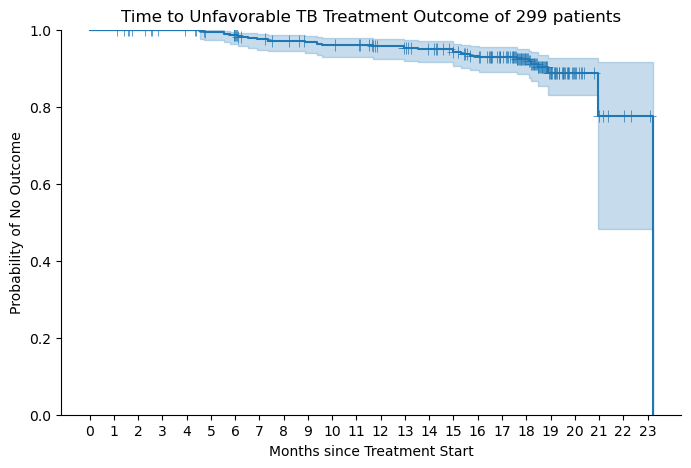

In [42]:
fig, ax = plt.subplots(figsize=(8, 5))

if tb_deaths_only:
    df_tx_outcomes.loc[(df_tx_outcomes["TB_death"]==0) & (df_tx_outcomes["event"]==1), "event"] = 0

kmf_full = lifelines.KaplanMeierFitter()
kmf_full.fit(df_tx_outcomes['months'], event_observed=df_tx_outcomes['event'])
# print(kmf_full.median_survival_time_)
kmf_full.plot_survival_function(show_censors=True, censor_styles={"marker": "+", "ms": 8, "mew": 0.5})
# plt.ylim(0, 1)

# Set x-axis ticks to show all integers
# ax.set_xticks(range(0, df_outcomes['weeks'].max() + 1))

plt.title(f"Time to Unfavorable TB Treatment Outcome of {df_tx_outcomes.pid.nunique()} patients")
plt.ylabel("Probability of No Outcome") #
plt.xlabel("Months since Treatment Start")
plt.ylim(0, 1)

# Set x-axis ticks to show all integers
ax.set_xticks(range(0, int(df_tx_outcomes['months'].max()) + 1))

plt.gca().get_legend().remove()

sns.despine()
plt.savefig("./results/figures/outcomes/KM_estimate.svg", bbox_inches='tight')

In [51]:
df_pred_combined

,pid,RIF_pred_MIC,INH_pred_MIC,EMB_pred_MIC,PZA_pred_MIC
0,T0002,0.061790,0.051422,1.228864,24.936577
1,T0003,0.059523,0.051391,1.244326,16.532267
2,T0004,0.060000,0.051584,1.169766,26.149416
3,T0005,0.060000,0.051584,1.169766,25.436100
4,T0008,0.060233,0.051921,0.931053,24.619717
...,...,...,...,...,...
294,T0471,0.060000,0.051584,1.169766,26.149416
295,T0472,0.063553,0.083249,1.232841,24.936577
296,T0474,0.059523,0.051391,1.245973,16.532267
297,T0475,0.060000,0.051584,1.169766,26.149416


In [61]:
df_test_results, df_samples_imputations, cph_models_imputations = fit_cox_models_all_imputations(df_pids_for_outcomes_model,
                                                                                                  df_pred_combined,
                                                                                                   TRUST_phenos,
                                                                                                  df_tx_outcomes,
                                                                                                  cols_lst,
                                                                                                  event_col = 'event',
                                                                                                  time_col = 'date',
                                                                                                  exclude_resistance=False,
                                                                                                  MIC_type=MIC_type,
                                                                                                 include_drugs=['RIF'],
                                                                                                 binarize_drugs=['RIF'],
                                                                                                  tb_deaths_only=tb_deaths_only,
                                                                                                  invert_OR=False,
                                                                                                  stratify_variables=stratify_covariates,
                                                                                                 binary_lineage=True
                                                                                                 )


# convert to HR per 10 years
OR_col = 'OR'
df_test_results.loc[df_test_results['covariate']=='screen_years', [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']] = df_test_results.loc[df_test_results['covariate']=='screen_years', [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']]**10

df_violating_covariates = []

for model_idx in range(len(cph_models_imputations)):

    df_proportional_hazards = lifelines.statistics.proportional_hazard_test(cph_models_imputations[model_idx], df_samples_imputations[model_idx], time_transform='rank').summary

    # diabetes has a p-value of like 0.0105
    violating_covariates = df_proportional_hazards.reset_index()[['index', 'p']].rename(columns={'index': 'covariate'})
    
    violating_covariates['imp_num'] = model_idx + 1

    df_violating_covariates.append(violating_covariates)

df_violating_covariates = pd.concat(df_violating_covariates)
df_violating_covariates.query("p <= 0.05")

Binarized RIF_pred_MIC at 0.05999994 µg/mL, 34.4% are high
    291 total pids


,covariate,p,imp_num
2,Lineage_2,0.002168,1
3,RIF_pred_MIC_high,0.001979,1


In [76]:
label_dict = {'INH_AUC': 'Predicted INH Exposure',
              'Lineage_2': 'Lineage 2',
              'TTP_baseline': 'Time to Culture Positivity',
              # 'bl_bmi': 'Body Mass Index',
              'underweight': 'BMI < 18',
              'bl_prevtb': 'Previous TB Disease',
              'diabetes': 'Diabetes',
              'fstrom1_baseline': 'Smoking',
              'inh_resistant': 'Isoniazid Resistant',
              'screen_sex': 'Male Sex',
              'screen_years': 'Age',
              'smear_pos_no_contam_sputum_specimen_1': 'Smear Positive at Baseline',
              'HIV_High_CD4': 'HIV+, CD4 ≥ 200 cells/mm\u00B3',
              'HIV_Low_CD4': 'HIV+, CD4 < 200 cells/mm\u00B3',
              'high_lung_involvement': '>20% Lung Affected',
              'smoked_substance_use': 'Smoked Substance Use',
              'peth_value_baseline': 'PEth Value',
              'RIF_pred_MIC_high': 'Predicted RIF MIC ≥ 0.06 µg/mL',
             }

forest_plot(df_test_results.sort_values("pval", ascending=True), 
            df_test_results.sort_values("pval", ascending=True).covariate.unique(),
            label_dict, 
            val_col='OR', 
            alpha=0.05, 
            log=True, 
            pval_offset=1.05, 
            df_stratify_variables_results=None, 
            saveName="./results/figures/outcomes/base_model_lowF2.png"
           )

In [46]:
close_variants_lst = []

for i, row in df_variants.drop_duplicates(subset=['POS', 'variant']).reset_index(drop=True).iterrows():
    
    variant = row['variant']
    
    if variant not in close_variants_lst:
        
        # get all variants within 10 nts
        close_variant_idx = np.where(np.abs(row['POS'] - df_variants.query("variant != @variant")['POS']) <= 10)[0]

        if len(close_variant_idx) > 0:

            close_variants = np.unique(df_variants.query("variant != @variant").variant.values[close_variant_idx])

            close_variants_lst.append(list(close_variants) + [variant])

    if i % 100 == 0:
        print(i)
        
print(len(close_variants_lst))

df_close_variants = pd.DataFrame(close_variants_lst, columns = ['Variant1', 'Variant2'])

# Ensure a consistent ordering for the pair
df_close_variants["Paired"] = df_close_variants.apply(lambda row: tuple(sorted([row["Variant1"], row["Variant2"]])), axis=1)

# Drop duplicates based on the normalized pair
df_close_variants = df_close_variants.drop_duplicates(subset="Paired").drop(columns="Paired")

print(len(df_close_variants))

df_close_variants.query("~Variant1.str.contains('_p.') & ~Variant2.str.contains('_p.') & ((Variant1.str.contains('ins') & Variant2.str.contains('ins')) | (Variant1.str.contains('del') & Variant2.str.contains('del')))")

0
100
200
300
22
11


,Variant1,Variant2
0,Rv0759c_c.-97_-96delGG,Rv0759c_c.-96delG
1,htrA_c.-38_-37insG,htrA_c.-38_-37insGG


In [72]:
# df_results_all_indels_outcomes = []

# test_variants_lst = np.concatenate([coding_change_variants, noncoding_change_variants])

# # remove these 4 and add
# test_variants_lst = list(set(test_variants_lst) - set(['Rv0759c_c.-97_-96delGG', 'Rv0759c_c.-96delG', 'htrA_c.-38_-37insG', 'htrA_c.-38_-37insGG']))

# print(f"Testing associations between poor outcomes and {len(test_variants_lst)} phase variants")

# # for variant in gene_grouping_dict.keys():
# for variant in test_variants_lst:
    
#     print(f"Testing {variant}")

#     df_imputed_patient_data_single_variant = add_change_to_indel_to_patient_data(df_pids_for_outcomes_model,#.query("Lineage=='2'"), 
#                                                                                      sample_1_variants,
#                                                                                      sample_2_variants,
#                                                                                      indels_difference,
#                                                                                      variant,
#                                                                                      freq_thresh=2,
#                                                                                  include_interaction=False,
#                                                                                      )

#     # will be None if there are not enough patients with the specified change in the indel
#     if df_imputed_patient_data_single_variant is not None:
    
#         df_test_results_indel, _, _ = fit_cox_models_all_imputations(df_imputed_patient_data_single_variant,
#                                                                       df_pred_combined,
#                                                                        TRUST_phenos,
#                                                                       df_tx_outcomes,
#                                                                      cols_lst + ['Indel_Change'],
#                                                                       event_col = 'event',
#                                                                       time_col = 'date',
#                                                                       invert_OR=False,
#                                                                       MIC_type=MIC_type,
#                                                                      include_drugs=['RIF'],
#                                                                       binarize_drugs=['RIF'],
#                                                                       stratify_variables=stratify_covariates,
#                                                                      binary_lineage=True
#                                                                      )

    
#         df_test_results_indel['Indel'] = variant
    
#         df_results_all_indels_outcomes.append(df_test_results_indel)
        
        
# paired_variants_lst = [['Rv0759c_c.-96delG', 'Rv0759c_c.-97_-96delGG'],
#                        ['htrA_c.-38_-37insG', 'htrA_c.-38_-37insGG']
#                       ]


# for variants_lst in paired_variants_lst:
    
#     df_imputed_patient_data_single_variant = df_pids_for_outcomes_model.merge(indels_difference[variants_lst], left_on='pid', right_index=True)

#     # messes with the names (underscores, periods), so rename
#     df_imputed_patient_data_single_variant.rename(columns={variants_lst[0]: 'Indel_1', variants_lst[1]: 'Indel_2'}, inplace=True)

#     df_test_results_indel, _, _ = fit_cox_models_all_imputations(df_imputed_patient_data_single_variant,
#                                                                   df_pred_combined,
#                                                                    TRUST_phenos,
#                                                                   df_tx_outcomes,
#                                                                  cols_lst + ['Indel_1', 'Indel_2'],
#                                                                   event_col = 'event',
#                                                                   time_col = 'date',
#                                                                   invert_OR=False,
#                                                                   MIC_type=MIC_type,
#                                                                  include_drugs=['RIF'],
#                                                                 binarize_drugs=['RIF'],
#                                                                   stratify_variables=stratify_covariates,
#                                                                  binary_lineage=True
#                                                                  )
    
#     df_test_results_indel['Indel'] = variants_lst[0].split('_')[0]
#     df_results_all_indels_outcomes.append(df_test_results_indel)
    

# df_results_all_indels_outcomes = pd.concat(df_results_all_indels_outcomes)

# fName = "./results/outcomes/indel_change_lowF2.csv"

# df_results_all_indels_outcomes.to_csv(fName, index=False)
# df_results_all_indels_outcomes = pd.read_csv(fName)

In [73]:
fName = "./results/outcomes/indel_change_lowF2.csv"

df_results_all_indels_outcomes = pd.read_csv(fName)

In [75]:
df_results_all_indels_outcomes.query("pval <= 0.05").drop_duplicates(subset='covariate')

,covariate,coef,exp(coef),se(coef),coef_transformed,se_transformed,imp_num,pval,OR,OR_lower,OR_upper,Indel
0,RIF_pred_MIC_high,1.349871,3.856927,0.485085,2.818563,1.012869,1,0.005390,16.752761,2.301074,121.966948,espR_c.-145_-144insG
4,Lineage_2,1.233707,3.433936,0.502976,2.465282,1.005082,1,0.014174,11.766797,1.641084,84.369545,espR_c.-145_-144insG


In [83]:
df_variants.query("variant.str.contains('Rv0759c') & variant.str.contains('delGG')")#.POS.unique()

,SampleID,pid,Sampling_Week,POS,REF,ALT,QUAL,DP,DPB,RO,...,Lineage,Coll2014,HT,variant,Diff_NT,Unique_Change_NT,Phase_Variant,SNP,Low_Qual,Paired_Sample_Num
327,MFS-29,T0049,8,854252,GCC,G,6775.09,223,188.923,0,...,4,4.1.1.1,1,Rv0759c_c.-97_-96delGG,CC,1.0,1,0,NaN,2
836,MFS-56,T0106,1,854252,GCC,G,7749.28,255,215.923,0,...,4,4.1.1.3,1,Rv0759c_c.-97_-96delGG,CC,1.0,1,0,NaN,1
5867,MFS-588,T0125,1,854252,GCC,G,9804.43,323,274.000,0,...,4,4.1,1,Rv0759c_c.-97_-96delGG,CC,1.0,1,0,NaN,1
5885,MFS-589,T0125,8,854252,GCC,G,7198.26,238,201.385,0,...,4,4.1,1,Rv0759c_c.-97_-96delGG,CC,1.0,1,0,NaN,2
7068,MFS-564,T0091,1,854252,GCC,G,8909.57,296,250.462,0,...,4,4.1.1.1,1,Rv0759c_c.-97_-96delGG,CC,1.0,1,0,NaN,1
7182,MFS-605,T0149,5,854252,GCC,G,9612.61,317,268.462,0,...,4,4.1.1.1,1,Rv0759c_c.-97_-96delGG,CC,1.0,1,0,NaN,2
8016,MFS-175,T0257,7,854252,GCC,G,9693.71,321,272.385,0,...,4,4.1.1.1,1,Rv0759c_c.-97_-96delGG,CC,1.0,1,0,NaN,2
9030,MFS-44,T0077,6,854252,GCC,G,5893.26,196,165.846,0,...,4,4.1.2.1,1,Rv0759c_c.-97_-96delGG,CC,1.0,1,0,NaN,2
10299,MFS-633,T0205,1,854252,GCC,G,8101.05,268,227.385,0,...,4,4.1.1.1,1,Rv0759c_c.-97_-96delGG,CC,1.0,1,0,NaN,1
10818,MFS-736,T0091,5,854252,GCC,G,17282.10,482,407.923,0,...,4,4.1.1.1,1,Rv0759c_c.-97_-96delGG,CC,1.0,1,0,NaN,2


In [48]:
def plot_survival_curve_by_indel_baseline(df_patient_data, df_outcome, event_variable, duration_variable, variant, sample_1_variants, exclude_fixed_absent=False, change_thresh=0.05, fixed_thresh=0.95, freq_thresh=5, logrank_test_compare_groups=['Gain', 'Loss'], colors_dict = {'Gain': '#1f77b4', 'Loss': '#ff7f0e', 'Fixed': '#d62728', 'Absent': '#2ca02c'}, p=0, q=0, save=False):

    if '.imp' in df_outcome.columns:
        df_outcome.rename(columns={'.imp': 'imp_num'}, inplace=True)
        
    if 'imp_num' not in df_outcome.columns:
        df_outcome['imp_num'] = 0
    
    df_imputed_patient_data_single_variant = add_indel_at_baseline_to_patient_data(df_patient_data, 
                                                                                 sample_1_variants, 
                                                                                 variant, 
                                                                                )

    if df_imputed_patient_data_single_variant is not None:

        # for variable in stratify_covariates:
        df_plot_outcome = df_outcome.query("imp_num==1").merge(df_imputed_patient_data_single_variant[['pid', 'Indel_Sample1']], on='pid').reset_index(drop=True)

        df_plot_outcome.loc[(df_plot_outcome['Indel_Sample1'] <= change_thresh), 'Group'] = 'Absent'
        df_plot_outcome.loc[(df_plot_outcome['Indel_Sample1'] > change_thresh) & (df_plot_outcome['Indel_Sample1'] <= fixed_thresh), 'Group'] = 'Unfixed'
        df_plot_outcome.loc[(df_plot_outcome['Indel_Sample1'] > fixed_thresh), 'Group'] = 'Fixed'
        
        df_plot_outcome['Group'] = df_plot_outcome['Group'].replace('nan', np.nan)

        if sum(pd.isnull(df_plot_outcome['Group'])) > 0:
            print(df_plot_outcome.loc[pd.isnull(df_plot_outcome['Group'])])
            raise ValueError()

        fig, ax = plt.subplots()
                
        # sort so that 0 is plotted before 1
        for group in np.sort(df_plot_outcome['Group'].unique()):
            
            if not exclude_fixed_absent:
                df_single_group = df_plot_outcome.query("Group==@group")
                kmf = lifelines.KaplanMeierFitter()
                kmf.fit(df_single_group[duration_variable], event_observed=df_single_group[event_variable], label=group)
                kmf.plot_survival_function(ax=ax, color=colors_dict[group], show_censors=True, censor_styles={"marker": "+", "ms": 8, "mew": 0.5}, label=f"{group} = {len(df_single_group)}")
            else:
                if group not in ['Fixed', 'Absent']:
                    df_single_group = df_plot_outcome.query("Group==@group")
                    kmf = lifelines.KaplanMeierFitter()
                    kmf.fit(df_single_group[duration_variable], event_observed=df_single_group[event_variable], label=group)
                    kmf.plot_survival_function(ax=ax, color=colors_dict[group], show_censors=True, censor_styles={"marker": "+", "ms": 8, "mew": 0.5}, label=f"{group} = {len(df_single_group)}")            

        # weight = [S(t)]^p * [1 - S(t)]^q, where S(t) is the survival function. 
        # p = 1 and q = 1 weights the middle the most
        # p = 0 and q = 0 doesn't weight by the survival function
        logRank_test_full = lifelines.statistics.multivariate_logrank_test(event_durations=df_plot_outcome[duration_variable],
                                                                      groups=df_plot_outcome['Group'],
                                                                      event_observed=df_plot_outcome[event_variable],
                                                                      weightings='fleming-harrington',
                                                                      p = p, # p = 1 weights early times more
                                                                      q = q, # q = 1 weights late times more
                                                                     )
        
        assert len(logrank_test_compare_groups) == 2
        group_1, group_2 = logrank_test_compare_groups
        assert group_1 != group_2
        
        # p = 0 and q = 0 doesn't weight by the survival function
        logRank_test_2_groups = lifelines.statistics.multivariate_logrank_test(event_durations=df_plot_outcome.query("Group in @logrank_test_compare_groups")[duration_variable],
                                                                              groups=df_plot_outcome.query("Group in @logrank_test_compare_groups")['Group'],
                                                                              event_observed=df_plot_outcome.query("Group in @logrank_test_compare_groups")[event_variable],
                                                                              weightings='fleming-harrington',
                                                                              p = p, # p = 1 weights early times more
                                                                              q = q, # q = 1 weights late times more
                                                                             )

        print(f"{variant}: χ^2 = {logRank_test_full.test_statistic}, p = {logRank_test_full.p_value}")

        plt.xlabel("Weeks since Treatment Start")
        sns.despine()
        plt.legend(title='Indel State')        
        
        if duration_variable == 'TCC':
            plt.title(f"Time to Culture Conversion of {df_plot_outcome.pid.nunique()} patients\nstratified by changes in {variant}\np ({group_1} vs. {group_2}) = {np.round(logRank_test_2_groups.p_value, 2)}")
            plt.ylabel("Probability of\n Positive Sputum Culture") #
            
            if save:
                plt.savefig(f"./results/figures/TCC/{variant}_KM_curve.svg", bbox_inches='tight')
            else:
                plt.show()
                
        else:
            plt.ylabel("Probability of No Event")
            plt.title(f"Time to Unfavorable Outcomes of {df_plot_outcome.pid.nunique()} patients\nstratified by changes in {variant}\np ({group_1} vs. {group_2}) = {np.round(logRank_test_2_groups.p_value, 2)}")
            
            if save:
                plt.savefig(f"./results/figures/outcomes/{variant}_KM_curve.svg", bbox_inches='tight')
            else:
                plt.show()

        return df_plot_outcome

esx: χ^2 = 14.595680753989205, p = 0.0006769992607552614




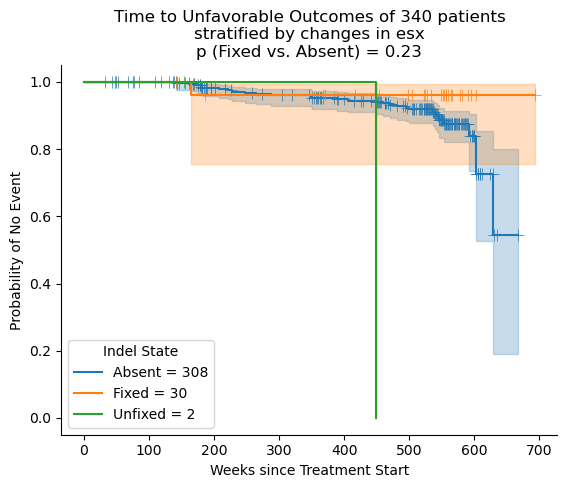

In [116]:
variant = 'esx'

pids_with_variant = sample_1_variants_grouped_pathways.loc[(sample_1_variants_grouped_pathways[variant] <= 0.75) & (sample_1_variants_grouped_pathways[variant] >= 0.05)].index.values

df_plot_outcome = plot_survival_curve_by_indel_baseline(df_imputed_patient_data_outcomes.query("pid not in @high_F2_pids.pid.values"),
                                                       df_tx_outcomes.query("pid in @df_trust_patients.pid"), # require this to exclude pid T0402 which has discordant WGS
                                                       'event',
                                                       'date',
                                                       variant,
                                                       sample_1_variants_grouped_pathways, 
                                                       exclude_fixed_absent=False,
                                                       change_thresh=0.05, 
                                                       freq_thresh=5,
                                                       logrank_test_compare_groups=['Fixed', 'Absent'], 
                                                       colors_dict = {'Fixed': '#ff7f0e', 'Absent': '#1f77b4', 'Unfixed': '#2ca02c', 'Loss': '#d62728'},
                                                       p=0,
                                                       q=0,
                                                       save=True
                                                      )

print("\n")

Rv0759c_c.-97_-96delGG: χ^2 = 9.542945791834331, p = 0.008467898636888313


PE_PGRS60: χ^2 = 4.007818429216499, p = 0.04528971639536179




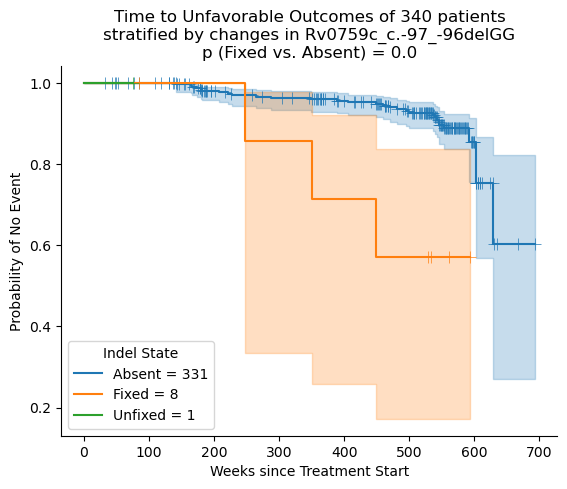

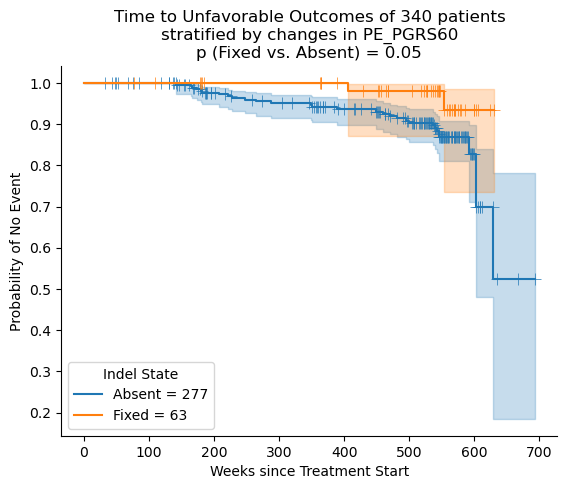

In [87]:
for i, row in df_results_all_indels_outcomes.query("pval <= 0.05 & covariate.str.contains('Indel')")[['covariate', 'Indel', 'OR_lower', 'OR', 'OR_upper']].iterrows():
    
    variant = row['Indel']
    
    pids_with_variant = sample_1_variants.loc[(sample_1_variants[variant] <= 0.75) & (sample_1_variants[variant] >= 0.05)].index.values
        
    df_plot_outcome = plot_survival_curve_by_indel_baseline(df_imputed_patient_data_outcomes.query("pid not in @high_F2_pids.pid.values"),
                                                           df_tx_outcomes.query("pid in @df_trust_patients.pid"), # require this to exclude pid T0402 which has discordant WGS
                                                           'event',
                                                           'date',
                                                           variant,
                                                           sample_1_variants, 
                                                           exclude_fixed_absent=False,
                                                           change_thresh=0.05, 
                                                           freq_thresh=5,
                                                           logrank_test_compare_groups=['Fixed', 'Absent'], 
                                                           colors_dict = {'Fixed': '#ff7f0e', 'Absent': '#1f77b4', 'Unfixed': '#2ca02c', 'Loss': '#d62728'},
                                                           p=0,
                                                           q=0,
                                                           save=True
                                                          )

    print("\n")

In [88]:
variant = 'PE_PGRS60'

label_dict = {'RIF_AUC': 'Rifampicin PK AUC',
              'INH_AUC': 'Isoniazid PK AUC',
              'EMB_AUC': 'Ethambutol PK AUC',
              'PZA_AUC': 'Pyrazinamide PK AUC',
              'screen_sex': 'Sex',
              'screen_years': 'Age',
              'bl_bmi': 'Body Mass Index',
              'smoked_substance_use': 'Smoked Substance Use',
              'HIV_High_CD4': 'HIV, CD4 ≥ 200 cells/$\mathregular{mm^3}$',
              'HIV_Low_CD4': 'HIV, CD4 < 200 cells/$\mathregular{mm^3}$',
              'INH_midpoing': 'Measured INH MIC',
              'bl_prevtb': 'Previous TB Disease',
              'smear_pos_no_contam_sputum_specimen_1': 'Smear Positivity',
              'diabetes': 'Diabetes',
              'Indel_Change': f'{variant} Gain',
              'Indel_Sample1': f'Frameshift in {variant}',
              'Indel_Sample1_x_Change': f'{variant} at Baseline x Gain',
              'Lineage_3': 'Lineage 3',
              'Lineage_4': 'Lineage 4',
              'total_adherence': 'Adherence Rate',
              'F2': 'F2 Strain Mixing Metric',
              'inh_resistant': 'INH Resistance',
              'high_lung_involvement': '>20% Lung Affected',
              'cxr_cavity_chest_radiograph_1': 'Cavitation',
              'fstrom1_baseline': 'Smoking',
              'Lineage_1': 'Lineage 1',
              'Lineage_3': 'Lineage 3',
              'Lineage_4': 'Lineage 4'
             }

forest_plot(df_results_all_indels_outcomes.query("Indel==@variant"), label_dict, val_col='OR', alpha=0.05, log=True, saveName=f"./results/figures/outcomes/{variant}_forest_plot.svg")

In [90]:
variant = 'Rv0759c_c.-97_-96delGG'

label_dict = {'RIF_AUC': 'Rifampicin PK AUC',
              'INH_AUC': 'Isoniazid PK AUC',
              'EMB_AUC': 'Ethambutol PK AUC',
              'PZA_AUC': 'Pyrazinamide PK AUC',
              'screen_sex': 'Sex',
              'screen_years': 'Age',
              'bl_bmi': 'Body Mass Index',
              'smoked_substance_use': 'Smoked Substance Use',
              'HIV_High_CD4': 'HIV, CD4 ≥ 200 cells/$\mathregular{mm^3}$',
              'HIV_Low_CD4': 'HIV, CD4 < 200 cells/$\mathregular{mm^3}$',
              'INH_midpoing': 'Measured INH MIC',
              'bl_prevtb': 'Previous TB Disease',
              'smear_pos_no_contam_sputum_specimen_1': 'Smear Positivity',
              'diabetes': 'Diabetes',
              'Indel_Change': f'{variant} Gain',
              'Indel_Sample1': f'{variant}',
              'Indel_Sample1_x_Change': f'{variant} at Baseline x Gain',
              'Lineage_3': 'Lineage 3',
              'Lineage_4': 'Lineage 4',
              'total_adherence': 'Adherence Rate',
              'F2': 'F2 Strain Mixing Metric',
              'inh_resistant': 'INH Resistance',
              'high_lung_involvement': '>20% Lung Affected',
              'cxr_cavity_chest_radiograph_1': 'Cavitation',
              'fstrom1_baseline': 'Smoking',
              'Lineage_1': 'Lineage 1',
              'Lineage_3': 'Lineage 3',
              'Lineage_4': 'Lineage 4'
             }

forest_plot(df_results_all_indels_outcomes.query("Indel==@variant"), label_dict, val_col='OR', alpha=0.05, log=True, saveName=f"./results/figures/outcomes/{variant}_forest_plot.svg")



In [99]:
pids_with_variant = list(set(sample_1_variants.loc[sample_1_variants[variant] > 0].index.values).intersection(df_tx_outcomes.pid))

df_trust_patients.query("pid in @pids_with_variant")[['pid', 'Lineage', 'inh_resistant']]

,pid,Lineage,inh_resistant
45,T0049,4.0,0.0
71,T0077,4,0.0
91,T0106,4,0.0
94,T0110,4,0.0
109,T0125,4,0.0
130,T0149,4,0.0
182,T0205,4,0.0
193,T0217,2.0,0.0
229,T0257,4,0.0


In [104]:
non_coding_regions = h37Rv_regions.query("Feature != 'CDS'").Name.values

In [108]:
df_variants.query("GENE in @non_coding_regions").drop_duplicates(subset=['variant', 'pid']).variant.value_counts()

variant
F6_n.30dupC       317
mcr11_n.95delC    220
Name: count, dtype: int64

In [138]:
4094527-4093940

587

In [91]:
PE_PGRS60_start = h37Rv_genes.query("Symbol == 'PE_PGRS60'").Start.values[0]
PE_PGRS60_end = h37Rv_genes.query("Symbol == 'PE_PGRS60'").End.values[0]

In [123]:
PE_PGRS60_AA = h37Rv_seq.seq[PE_PGRS60_start-1:PE_PGRS60_end].translate()

# delete G at 4093880
del_pos = 4093880

# skip the deletion position
PE_PGRS60_frameshifted_NT = h37Rv_seq.seq[PE_PGRS60_start-1:del_pos-1] + h37Rv_seq.seq[del_pos:]
PE_PGRS60_frameshifted_AA = PE_PGRS60_frameshifted_NT.translate()

# PE_PGRS60 is 104 AA long, and PE_PGRS61 is 195 AA long. The frameshifted protein would terminate at 221 AA long, which is 74% of the length
stop_codon_pos = PE_PGRS60_frameshifted_AA.find("*")
stop_codon_pos

221

In [136]:
PE_PGRS60_frameshifted_AA[:stop_codon_pos]

Seq('MSYVIAAPEALVAAATDLATLGSTIGAANAAAAGSTTALLTAGADEVSAAIAAY...VGR')

In [133]:
# in Mtb 18B assembly, they are one ORF, which is 306 AA long
Mtb_18B_PE_PGRS6061_NT = Seq.Seq("gtgtccgatgtcatatgtgatcgcggcgccggaggcgctggtggcggcggccacggatttggctactctcggctcgacgatcggcgccgccaacgcggccgctgcgggctcgacaacggcgttgctgaccgccggcgccgacgaagtgtcggcggcgatagcggcctattcggaatgcacggccagacctatcaggcactcagtgcgcgggcggcggcgttccatgagcggttcgtgcaggccttggccacaggtgggggcgcctatgcggccgccgaggccgccagcgtctcgccgctgcagagcgcgctcgatttgctgaatgcgcccactcaggcgctgttggggcgtccgttggtgggcaatggcgccaatggggccccggggactggggcaaacggcggcgatggcgggattttgttcgggtccgggggggccggcgggtccggagcggccggcatggcgggtggcaacggcggggccgccgggctgttcggcaacggcggagccggcggagccggcggcagcgcgacggccggtgcggccggggcgggcgggaacggcggggccggcgggctgctgttcggtaccgccggggccggcggcaacggcgggttaagcctcggtttgggcgtcgccggcggcgccggcggcgccggcgggtcgggcggtagtgacaccgccggacacggggggaccggtggtgccggcggcctgctattcggcgccggcggcgccggcggcgccggcgaggacggcacaacgcccggtggcaacggtggggcgggcggtgtcgccgggctgttcggcgacggcggcaacggtggtaacgccggagttggcacgcccgcgggcaacgtcggcgccggcggcaccggcggcctgctgctcggccaggacggcatgaccgggttgacgtag")

Mtb_18B_PE_PGRS6061_AA = Mtb_18B_PE_PGRS6061_NT.translate()

In [134]:
Mtb_18B_PE_PGRS6061_AA

Seq('VSDVICDRGAGGAGGGGHGFGYSRLDDRRRQRGRCGLDNGVADRRRRRSVGGDS...LT*')

In [137]:
len(Mtb_18B_PE_PGRS6061_AA)

307

In [109]:
h37Rv_seq.seq[PE_PGRS60_start-1:del_pos-1] + Seq.Seq('A')

Seq('ATGTCATATGTGATCGCGGCGCCGGAGGCGCTGGTGGCGGCGGCCACGGATTTG...GTA')

In [104]:
h37Rv_seq.seq[PE_PGRS60_start-1:4093879]

Seq('ATGTCATATGTGATCGCGGCGCCGGAGGCGCTGGTGGCGGCGGCCACGGATTTG...GGT')

In [ ]:
h37Rv_seq.seq[PE_PGRS60_start-1:4093879]

In [100]:
h37Rv_seq[4093880-1]

'G'

In [97]:
PE_PGRS60_AA

Seq('MSYVIAAPEALVAAATDLATLGSTIGAANAAAAGSTTALLTAGADEVSAAIAAY...IC*')

In [99]:
df_variants.query("GENE=='PE_PGRS60'")

,pid,SampleID,POS,REF,ALT,QUAL,DP,DPB,RO,AO,...,variant,SRP_prob,SAP_prob,HT,Diff_NT,Unique_Change_NT,Phase_Variant,SNP,Sampling_Week,Paired_Sample_Num
9,T0001,MFS-331,4093879,TG,T,7245.65,240,213.333,0,240.0,...,PE_PGRS60_p.Ala85fs,NaN,0.059222,1,G,1.0,1,0,1.0,1
22,T0002,MFS-509,4093879,TG,T,7021.44,232,206.333,0,232.0,...,PE_PGRS60_p.Ala85fs,NaN,0.005229,1,G,1.0,1,0,1.0,1
34,T0002,MFS-510,4093879,TG,T,6089.29,202,179.556,0,202.0,...,PE_PGRS60_p.Ala85fs,NaN,0.150896,1,G,1.0,1,0,5.0,2
638,T0013,MFS-6,4093879,TG,T,8012.36,265,235.667,0,265.0,...,PE_PGRS60_p.Ala85fs,NaN,0.005389,1,G,1.0,1,0,9.0,2
674,T0016,MFS-519,4093879,TG,T,6214.21,206,183.111,0,206.0,...,PE_PGRS60_p.Ala85fs,NaN,0.001863,1,G,1.0,1,0,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19898,T0437,MFS-702,4093879,TG,T,6608.17,219,194.667,0,219.0,...,PE_PGRS60_p.Ala85fs,NaN,0.073296,1,G,1.0,1,0,1.0,1
19912,T0437,MFS-819,4093879,TG,T,6288.74,180,160.111,0,178.0,...,PE_PGRS60_p.Ala85fs,NaN,0.377552,1,G,1.0,1,0,5.0,2
20225,T0444,MFS-707,4093879,TG,T,2636.85,287,266.333,101,186.0,...,PE_PGRS60_p.Ala85fs,0.334828,0.022356,1,G,1.0,1,0,1.0,1
20612,T0452,MFS-714,4093879,TG,T,6932.99,231,205.333,0,230.0,...,PE_PGRS60_p.Ala85fs,NaN,0.000883,1,G,1.0,1,0,1.0,1


In [112]:
df_variants.query("variant==@variant").Lineage.value_counts()

Lineage
4.0    18
4       2
2.0     1
2.0     1
Name: count, dtype: int64

In [113]:
df_variants.query("variant==@variant").Coll2014.value_counts()

Coll2014
4.1.1.1    14
4.1.2.1     2
4.1.1.3     2
4.1         2
2.2.1.1     2
Name: count, dtype: int64

In [117]:
df_variants.query("variant==@variant & AF <= 0.75")[['pid', 'SampleID', 'F2', 'POS', 'REF', 'ALT', 'DP', 'AO', 'AF']]

,pid,SampleID,F2,POS,REF,ALT,DP,AO,AF
21578,T0217,MFS-758,0.011056,854252,GCC,G,290,173.0,0.596552


In [120]:
df_variants.query("variant==@variant & pid=='T0217'")[['pid', 'SampleID', 'F2', 'POS', 'REF', 'ALT', 'DP', 'AO', 'AF', 'Sampling_Week', 'Paired_Sample_Num']].sort_values('Paired_Sample_Num')

,pid,SampleID,F2,POS,REF,ALT,DP,AO,AF,Sampling_Week,Paired_Sample_Num
21578,T0217,MFS-758,0.011056,854252,GCC,G,290,173.0,0.596552,1,1
9802,T0217,MFS-759,0.011409,854252,GCC,G,231,174.0,0.753247,5,2


In [121]:
df_tx_outcomes.query("pid=='T0217'")

,pid,date,event_type,to_studyto_treatment_outcome,esp_reason_end_of_study_parti,esp_reasonoth_end_of_study_parti,esp_date_end_of_study_parti,waiver_reason_end_of_study_parti,esp_cod_end_of_study_parti,waiver_deathcause_end_of_study_parti,TB_death,event,reenroll,unique_patient,weeks,months,imp_num
180,T0217,76.0,cure,3.0,7.0,NaN,217.0,NaN,NaN,NaN,NaN,0,0,227,10.857143,2.533333,0


In [129]:
df_trust_patients.columns[df_trust_patients.columns.str.contains('comment', case=False)]

Index(['Comment', 'comment', 'inh_dst_comment_sputum_specimen_13',
       'rif_dst_comment_sputum_specimen_13', 'to_comments_treatment_outcome',
       'dna_comments_dna_extract_1', 'dna_comments_dna_extract_2'],
      dtype='object')

In [132]:
df_trust_patients.query("pid=='T0217'")[['to_comments_treatment_outcome', 'comment']].to_comments_treatment_outcome.values

array(['Verbal confirmation from Sr at TB Clinic that patient is regarded as "Treatment Defaulted" as she was loss to follow-up (no treatment received for more than two months). Did not finish TB Treatment.',
       'Verbal confirmation from Sr at TB Clinic that patient is regarded as "Treatment Defaulted" as she was loss to follow-up (no treatment received for more than two months). Did not finish TB Treatment.'],
      dtype=object)

In [68]:
sample_1_variants.loc[(sample_1_variants['PE_PGRS60'] <= 0.75) & (sample_1_variants['PE_PGRS60'] > 0)]['PE_PGRS60']

T0444    0.648084
T0087    0.404167
T0072    0.400901
T0066    0.059524
T0311    0.323404
T0305    0.525773
T0267    0.213953
Name: PE_PGRS60, dtype: float64

In [53]:
df_variants.query("GENE=='PE_PGRS60'")[['POS', 'REF', 'ALT', 'variant']].drop_duplicates()

,POS,REF,ALT,variant
9,4093879,TG,T,PE_PGRS60_p.Ala85fs


In [57]:
df_variants.query("GENE=='PE_PGRS60'").sort_values("SampleID")[['pid', 'SampleID', 'SAF', 'SAR', 'SAP_prob']]

,pid,SampleID,SAF,SAR,SAP_prob
892,T0021,MFS-10,70.0,142.0,0.000002
8288,T0186,MFS-104,83.0,94.0,0.355243
8301,T0186,MFS-105,61.0,84.0,0.080679
8400,T0188,MFS-106,72.0,97.0,0.078688
8687,T0196,MFS-111,97.0,99.0,0.494923
...,...,...,...,...,...
20126,T0452,MFS-831,93.0,102.0,0.406228
879,T0021,MFS-9,63.0,97.0,0.013492
7715,T0171,MFS-90,98.0,143.0,0.007488
7768,T0173,MFS-91,74.0,116.0,0.004819


In [146]:
for variant in df_results_all_indels_outcomes.query("pval <= 0.05 & covariate.str.contains('Indel')").Indel.values:
    
    pids_with_variant = sample_1_variants.loc[sample_1_variants[variant]==1].index.values
    
    print(variant, pids_with_variant)

fhaB_c.-36delG ['T0187' 'T0233' 'T0272' 'T0380' 'T0384']
Rv0759c_c.-97_-96delGG ['T0049' 'T0077' 'T0091' 'T0106' 'T0125' 'T0149' 'T0205' 'T0257' 'T0330']
Rv3128c_c.-139_-140insCC,Rv3129_c.-340_-339insCC ['T0187' 'T0233' 'T0272' 'T0380' 'T0384']
Rv0192 ['T0187' 'T0233' 'T0272' 'T0380' 'T0384']
Rv1215c ['T0049' 'T0091' 'T0149' 'T0205' 'T0257' 'T0330']
PE_PGRS31 ['T0049' 'T0091' 'T0149' 'T0205' 'T0257' 'T0330']
mce3B ['T0187' 'T0233' 'T0272' 'T0380' 'T0384']
ahpD ['T0049' 'T0091' 'T0149' 'T0205' 'T0257' 'T0330']


In [ ]:
# ['T0049' 'T0091' 'T0149' 'T0205' 'T0257' 'T0330'] have the variants in
# Rv0759c_c.-97_-96delGG, Rv1215c, PE_PGRS31, and ahpD

In [199]:
pids_with_same_variants = ['T0049', 'T0091', 'T0149', 'T0205', 'T0257', 'T0330']
sample_1_variants.loc[pids_with_same_variants, ['Rv0759c_c.-97_-96delGG', 'Rv1215c', 'PE_PGRS31', 'ahpD']]

,Rv0759c_c.-97_-96delGG,Rv1215c,PE_PGRS31,ahpD
T0049,1.0,1.0,1.0,1.0
T0091,1.0,1.0,1.0,1.0
T0149,1.0,1.0,1.0,1.0
T0205,1.0,1.0,1.0,1.0
T0257,1.0,1.0,1.0,1.0
T0330,1.0,1.0,1.0,1.0


In [202]:
df_variants.query("pid in @pids_with_same_variants").drop_duplicates(subset='pid').Coll2014.value_counts()

Coll2014
4.1.1.1    6
Name: count, dtype: int64

In [208]:
pids_for_analysis.query("pid in @pids_with_same_variants").columns

Index(['pid', 'Original_ID', 'SampleID', 'SampleLib', 'Pacbio', 'Comment',
       'quality', 'Cov_Any_Mean', 'Cov_Unam_Perc', 'Perc_Reads_Mapped',
       ...
       'last_dots_date', 'F2', 'Coll2014', 'Freschi2020', 'Lineage',
       'Sampling_Week', 'Paired_Sample_Num', 'Kraken_Unclassified_Percent',
       'high_F2', 'pid_high_F2'],
      dtype='object', length=7106)

In [209]:
df_variants

,pid,SampleID,Sampling_Week,Paired_Sample_Num,POS,REF,ALT,QUAL,DP,DPB,...,SAP_prob,F2,Lineage,Coll2014,HT,variant,Diff_NT,Unique_Change_NT,Phase_Variant,SNP


In [204]:
df_variants.query("pid in @pids_with_same_variants & GENE=='Rv1215c'")

,pid,SampleID,Sampling_Week,Paired_Sample_Num,POS,REF,ALT,QUAL,DP,DPB,...,SAP_prob,F2,Lineage,Coll2014,HT,variant,Diff_NT,Unique_Change_NT,Phase_Variant,SNP
1980,T0049,MFS-28,1,1,1358906,AC,A,4917.45,163,142.750,...,0.017710,0.008670,4,4.1.1.1,1,Rv1215c_p.Val180fs,C,1.0,1,0
1999,T0049,MFS-29,8,2,1358906,AC,A,5206.87,173,152.000,...,0.001436,0.008782,4,4.1.1.1,1,Rv1215c_p.Val180fs,C,1.0,1,0
3838,T0091,MFS-564,1,1,1358906,AC,A,5851.90,193,169.625,...,0.099031,0.008389,4,4.1.1.1,1,Rv1215c_p.Val180fs,C,1.0,1,0
3857,T0091,MFS-736,5,2,1358906,AC,A,13423.00,378,330.750,...,0.000507,0.007203,4,4.1.1.1,1,Rv1215c_p.Val180fs,C,1.0,1,0
5433,T0149,MFS-604,1,1,1358906,AC,A,6332.03,210,184.125,...,0.087408,0.004925,4,4.1.1.1,1,Rv1215c_p.Val180fs,C,1.0,1,0
5452,T0149,MFS-605,5,2,1358906,AC,A,7032.67,234,204.750,...,0.116479,0.012019,4,4.1.1.1,1,Rv1215c_p.Val180fs,C,1.0,1,0
7523,T0205,MFS-633,1,1,1358906,AC,A,6545.98,216,189.625,...,0.046723,0.006866,4,4.1.1.1,1,Rv1215c_p.Val180fs,C,1.0,1,0
7542,T0205,MFS-634,4,2,1358906,AC,A,6031.56,201,176.125,...,0.002521,0.005875,4,4.1.1.1,1,Rv1215c_p.Val180fs,C,1.0,1,0
9549,T0257,MFS-174,1,1,1358906,AC,A,6036.97,200,175.125,...,0.003953,0.008193,4,4.1.1.1,1,Rv1215c_p.Val180fs,C,1.0,1,0
9568,T0257,MFS-175,7,2,1358906,AC,A,7561.74,253,222.250,...,0.004186,0.008737,4,4.1.1.1,1,Rv1215c_p.Val180fs,C,1.0,1,0


In [184]:
# variant = 'mce3B'
variant = 'Rv0759c_c.-97_-96delGG'
pids_with_variant = sample_1_variants.loc[sample_1_variants[variant]==1].index.values

In [186]:
df_variants.query("pid in @pids_with_variant & variant==@variant")

,pid,SampleID,Sampling_Week,Paired_Sample_Num,POS,REF,ALT,QUAL,DP,DPB,...,SAP_prob,F2,Lineage,Coll2014,HT,variant,Diff_NT,Unique_Change_NT,Phase_Variant,SNP
1979,T0049,MFS-28,1,1,854252,GCC,G,6549.16,216,183.000,...,0.163079,0.008670,4,4.1.1.1,1,Rv0759c_c.-97_-96delGG,CC,1.0,1,0
1998,T0049,MFS-29,8,2,854252,GCC,G,6775.09,223,188.923,...,0.381194,0.008782,4,4.1.1.1,1,Rv0759c_c.-97_-96delGG,CC,1.0,1,0
3248,T0077,MFS-43,1,1,854252,GCC,G,8375.10,275,232.769,...,0.491884,0.021399,4,4.1.2.1,1,Rv0759c_c.-97_-96delGG,CC,1.0,1,0
3268,T0077,MFS-44,6,2,854252,GCC,G,5893.26,196,165.846,...,0.344976,0.021498,4,4.1.2.1,1,Rv0759c_c.-97_-96delGG,CC,1.0,1,0
3837,T0091,MFS-564,1,1,854252,GCC,G,8819.64,293,247.923,...,0.500000,0.008389,4,4.1.1.1,1,Rv0759c_c.-97_-96delGG,CC,1.0,1,0
3856,T0091,MFS-736,5,2,854252,GCC,G,17246.30,481,407.077,...,0.495344,0.007203,4,4.1.1.1,1,Rv0759c_c.-97_-96delGG,CC,1.0,1,0
4097,T0106,MFS-56,1,1,854252,GCC,G,7749.28,255,215.923,...,0.096119,0.018698,4,4.1.1.3,1,Rv0759c_c.-97_-96delGG,CC,1.0,1,0
4117,T0106,MFS-57,8,2,854252,GCC,G,9041.80,297,251.308,...,0.307377,0.017603,4,4.1.1.3,1,Rv0759c_c.-97_-96delGG,CC,1.0,1,0
4729,T0125,MFS-588,1,1,854252,GCC,G,9804.43,323,274.000,...,0.493082,0.023414,4,4.1,1,Rv0759c_c.-97_-96delGG,CC,1.0,1,0
4746,T0125,MFS-589,8,2,854252,GCC,G,7167.30,237,200.538,...,0.179322,0.020902,4,4.1,1,Rv0759c_c.-97_-96delGG,CC,1.0,1,0


In [187]:
df_tx_outcomes.query("pid in @pids_with_variant")

,pid,date,event_type,to_studyto_treatment_outcome,esp_reason_end_of_study_parti,esp_reasonoth_end_of_study_parti,esp_date_end_of_study_parti,waiver_reason_end_of_study_parti,esp_cod_end_of_study_parti,waiver_deathcause_end_of_study_parti,TB_death,event,reenroll,unique_patient,weeks,months,imp_num
39,T0049,449.0,relapse,2.0,5.0,NaN,449.0,NaN,NaN,NaN,NaN,1,0,21,64.142857,14.966667,0
63,T0077,534.0,cure,1.0,1.0,NaN,534.0,NaN,NaN,NaN,NaN,0,0,118,76.285714,17.800000,0
83,T0106,529.0,cure,1.0,1.0,NaN,529.0,NaN,NaN,NaN,NaN,0,0,140,75.571429,17.633333,0
99,T0125,593.0,cure,1.0,1.0,NaN,593.0,NaN,NaN,NaN,NaN,0,0,153,84.714286,19.766667,0
118,T0149,561.0,cure,1.0,1.0,NaN,561.0,NaN,NaN,NaN,NaN,0,0,172,80.142857,18.700000,0
170,T0205,84.0,cure,9.0,3.0,NaN,84.0,NaN,NaN,NaN,NaN,0,0,219,12.000000,2.800000,0
210,T0257,350.0,relapse,1.0,5.0,NaN,350.0,1.0,NaN,NaN,NaN,1,1,5,50.000000,11.666667,0


In [193]:
df_pred_combined.query("pid in @pids_with_variant")

,pid,RIF_pred_MIC,INH_pred_MIC,EMB_pred_MIC,PZA_pred_MIC
44,T0049,0.064936,0.049973,0.919206,24.936594
69,T0077,0.060977,0.050339,1.280068,24.756018
82,T0091,0.065054,3.285629,0.919206,24.936594
91,T0106,0.064164,0.051246,1.326902,24.936594
109,T0125,0.061919,0.050146,1.237477,25.042257
130,T0149,0.064936,0.049973,0.919206,24.936594
183,T0205,0.064936,0.049973,0.919206,24.936594
230,T0257,0.064936,0.049973,0.919206,24.936594
290,T0330,0.064936,0.049973,0.919206,24.936594


In [194]:
TRUST_phenos.query("pid in @pids_with_variant")

,pid,RIF_lower_bound,RIF_upper_bound,RIF_midpoint,INH_lower_bound,INH_upper_bound,INH_midpoint,EMB_lower_bound,EMB_upper_bound,EMB_midpoint,PZA_lower_bound,PZA_upper_bound,PZA_midpoint
241,T0091,0.030,0.060,0.0450,0.100,0.20,0.1500,0.6,1.25,0.925,NaN,NaN,NaN
2092,T0125,0.060,0.125,0.0925,0.025,0.05,0.0375,0.6,1.25,0.925,NaN,NaN,NaN
2175,T0149,0.125,0.250,0.1875,0.025,0.05,0.0375,0.6,1.25,0.925,25.0,50.0,37.5
2410,T0205,0.060,0.125,0.0925,0.025,0.05,0.0375,0.0,0.60,0.300,NaN,NaN,NaN
2539,T0330,0.060,0.125,0.0925,0.025,0.05,0.0375,0.6,1.25,0.925,0.0,25.0,12.5
3777,T0077,0.060,0.125,0.0925,0.025,0.05,0.0375,0.0,0.60,0.300,0.0,25.0,12.5
3860,T0049,0.125,0.250,0.1875,0.025,0.05,0.0375,0.6,1.25,0.925,NaN,NaN,NaN
4216,T0106,0.060,0.125,0.0925,0.025,0.05,0.0375,0.6,1.25,0.925,0.0,25.0,12.5
4457,T0257,0.060,0.125,0.0925,0.025,0.05,0.0375,0.6,1.25,0.925,25.0,50.0,37.5


In [155]:
df_variants.query("pid in ['T0049', 'T0091', 'T0149', 'T0205', 'T0257', 'T0330']").Coll2014.unique()

array(['4.1.1.1'], dtype=object)

In [152]:
df_variants.query("pid=='T0049' & GENE.str.contains('|'.join(['Rv0759c', 'Rv1215c', 'PE_PGRS31', 'ahpD']))")[['pid', 'SampleID', 'POS', 'REF', 'ALT', 'variant', 'Lineage']]

,pid,SampleID,POS,REF,ALT,variant,Lineage
1979,T0049,MFS-28,854252,GCC,G,Rv0759c_c.-97_-96delGG,4
1980,T0049,MFS-28,1358906,AC,A,Rv1215c_p.Val180fs,4
1984,T0049,MFS-28,2001878,CG,C,PE_PGRS31_p.Gly424fs,4
1988,T0049,MFS-28,2726815,GA,G,ahpD_p.Lys5fs,4
1998,T0049,MFS-29,854252,GCC,G,Rv0759c_c.-97_-96delGG,4
1999,T0049,MFS-29,1358906,AC,A,Rv1215c_p.Val180fs,4
2003,T0049,MFS-29,2001878,CG,C,PE_PGRS31_p.Gly424fs,4
2007,T0049,MFS-29,2726815,GA,G,ahpD_p.Lys5fs,4


In [31]:
df_variants.query("variant=='Rv0759c_c.-97_-96delGG' & F2 <= 0.03")[['REF', 'ALT', 'variant', 'AF', 'variant']]#.variant.value_counts()

,REF,ALT,variant,AF,variant
1979,GCC,G,Rv0759c_c.-97_-96delGG,1.000000,Rv0759c_c.-97_-96delGG
1998,GCC,G,Rv0759c_c.-97_-96delGG,1.000000,Rv0759c_c.-97_-96delGG
3248,GCC,G,Rv0759c_c.-97_-96delGG,1.000000,Rv0759c_c.-97_-96delGG
3268,GCC,G,Rv0759c_c.-97_-96delGG,0.989796,Rv0759c_c.-97_-96delGG
3837,GCC,G,Rv0759c_c.-97_-96delGG,0.989761,Rv0759c_c.-97_-96delGG
3856,GCC,G,Rv0759c_c.-97_-96delGG,1.000000,Rv0759c_c.-97_-96delGG
4097,GCC,G,Rv0759c_c.-97_-96delGG,1.000000,Rv0759c_c.-97_-96delGG
4117,GCC,G,Rv0759c_c.-97_-96delGG,1.000000,Rv0759c_c.-97_-96delGG
4729,GCC,G,Rv0759c_c.-97_-96delGG,1.000000,Rv0759c_c.-97_-96delGG
4746,GCC,G,Rv0759c_c.-97_-96delGG,0.995781,Rv0759c_c.-97_-96delGG


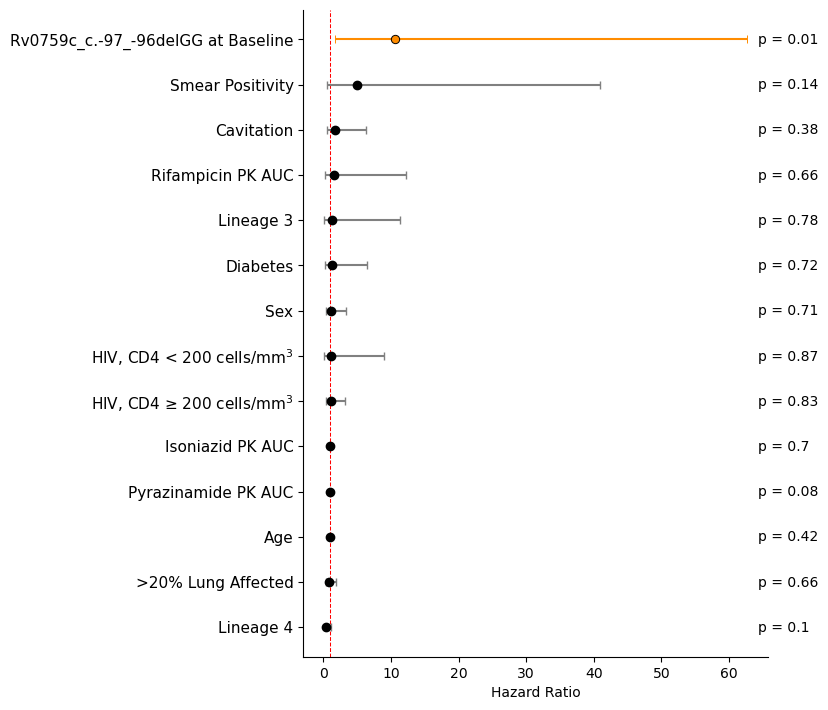

In [191]:
variant = 'Rv0759c_c.-97_-96delGG'
# variant = 'ahpD'

label_dict = {'RIF_AUC': 'Rifampicin PK AUC',
              'INH_AUC': 'Isoniazid PK AUC',
              'EMB_AUC': 'Ethambutol PK AUC',
              'PZA_AUC': 'Pyrazinamide PK AUC',
              'screen_sex': 'Sex',
              'screen_years': 'Age',
              'bl_bmi': 'Body Mass Index',
              'smoked_substance_use': 'Smoked Substance Use',
              'HIV_High_CD4': 'HIV, CD4 ≥ 200 cells/$\mathregular{mm^3}$',
              'HIV_Low_CD4': 'HIV, CD4 < 200 cells/$\mathregular{mm^3}$',
              'INH_midpoing': 'Measured INH MIC',
              'bl_prevtb': 'Previous TB Disease',
              'smear_pos_no_contam_sputum_specimen_1': 'Smear Positivity',
              'diabetes': 'Diabetes',
              'Indel_Change': f'{variant} Gain',
              'Indel_Sample1': f'{variant} at Baseline',
              'Indel_Sample1_x_Change': f'{variant} at Baseline x Gain',
              'Lineage_3': 'Lineage 3',
              'Lineage_4': 'Lineage 4',
              'total_adherence': 'Adherence Rate',
              'F2': 'F2 Strain Mixing Metric',
              'inh_resistant': 'INH Resistance',
              'high_lung_involvement': '>20% Lung Affected',
              'cxr_cavity_chest_radiograph_1': 'Cavitation',
              'fstrom1_baseline': 'Smoking'
             }

forest_plot(df_results_all_indels_outcomes.query("Indel==@variant & covariate != 'inh_resistant' & covariate != 'Indel_Change'"), label_dict, val_col='OR', alpha=0.05)#, saveName=f"./results/figures/outcomes/{variant}.svg")

In [32]:
variant = 'Rv0759c_c.-97_-96delGG'
pids_with_variant = sample_1_variants.loc[sample_1_variants[variant] > 0].index.values

In [33]:
df_tx_outcomes.query("pid in @pids_with_variant")

,pid,date,event_type,to_studyto_treatment_outcome,esp_reason_end_of_study_parti,esp_reasonoth_end_of_study_parti,esp_date_end_of_study_parti,waiver_reason_end_of_study_parti,esp_cod_end_of_study_parti,waiver_deathcause_end_of_study_parti,TB_death,event,reenroll,unique_patient,weeks,months
39,T0049,449.0,relapse,2.0,5.0,NaN,449.0,NaN,NaN,NaN,NaN,1,0,21,64.142857,14.966667
63,T0077,534.0,cure,1.0,1.0,NaN,534.0,NaN,NaN,NaN,NaN,0,0,118,76.285714,17.800000
83,T0106,529.0,cure,1.0,1.0,NaN,529.0,NaN,NaN,NaN,NaN,0,0,140,75.571429,17.633333
99,T0125,593.0,cure,1.0,1.0,NaN,593.0,NaN,NaN,NaN,NaN,0,0,153,84.714286,19.766667
118,T0149,561.0,cure,1.0,1.0,NaN,561.0,NaN,NaN,NaN,NaN,0,0,172,80.142857,18.700000
170,T0205,84.0,cure,9.0,3.0,NaN,84.0,NaN,NaN,NaN,NaN,0,0,219,12.000000,2.800000
180,T0217,76.0,cure,3.0,7.0,NaN,217.0,NaN,NaN,NaN,NaN,0,0,227,10.857143,2.533333
210,T0257,350.0,relapse,1.0,5.0,NaN,350.0,1.0,NaN,NaN,NaN,1,1,5,50.000000,11.666667


In [38]:
df_tx_outcomes.event_type.value_counts()

event_type
cure          230
relapse        18
death          11
tx_failure      4
Name: count, dtype: int64

In [34]:
df_imputed_patient_data_outcomes[['pid', 'inh_resistant']].query("pid in @pids_with_variant").drop_duplicates()

,pid,inh_resistant
39,T0049,0.0
63,T0077,0.0
83,T0106,0.0
100,T0125,0.0
119,T0149,0.0
171,T0205,0.0
181,T0217,0.0
212,T0257,0.0
270,T0330,0.0


In [35]:
df_pred_combined.query("pid in @pids_with_variant")

NameError: name 'df_pred_combined' is not defined

In [36]:
sample_1_variants.loc[sample_1_variants[variant] > 0][variant]

T0049    1.000000
T0077    1.000000
T0091    0.989761
T0106    1.000000
T0125    1.000000
T0149    0.992424
T0205    0.996296
T0217    0.596552
T0257    1.000000
T0330    0.995516
Name: Rv0759c_c.-97_-96delGG, dtype: float64

In [37]:
sample_2_variants.loc[sample_2_variants[variant] > 0][variant]

T0049    1.000000
T0077    0.989796
T0091    1.000000
T0106    1.000000
T0125    0.995781
T0149    0.996835
T0205    0.984375
T0217    0.753247
T0257    0.993769
T0330    1.000000
Name: Rv0759c_c.-97_-96delGG, dtype: float64

In [283]:
indels_difference[variant].value_counts()

Rv0759c_c.-97_-96delGG
 0.000000    267
-0.009950      1
 0.009868      1
-0.004049      1
-0.007475      1
 0.164983      1
-0.005848      1
 0.004255      1
Name: count, dtype: int64

In [144]:
search_pids = sample_1_variants.loc[sample_1_variants[variant] > 0.05].index.values
len(search_pids)

9

In [145]:
df_tx_outcomes.query("pid in @search_pids")[['pid', 'event_type', 'date', 'event']]

,pid,event_type,date,event
39,T0049,relapse,449.0,1
63,T0077,cure,534.0,0
83,T0106,cure,529.0,0
99,T0125,cure,593.0,0
170,T0205,cure,84.0,0
180,T0217,cure,76.0,0
210,T0257,relapse,350.0,1


In [277]:
df_imputed_patient_data_single_variant.loc[df_imputed_patient_data_single_variant['.imp']==0].query("pid in @search_pids").T

,39,63,83,100,171,181,212
.imp,0,0,0,0,0,0,0
.id,40,64,84,101,172,182,213
pid,T0049,T0077,T0106,T0125,T0205,T0217,T0257
screen_sex,0,1,1,0,1,0,0
screen_years,32,53,56,61,32,18,48
bl_bmi,16.3,13.3,20.3,35.5,17.8,13.9,21.1
fstrom1_baseline,0,1,0,1,1,1,1
bl_hiv,1,0,0,0,1,0,0
bl_cd4,1005.0,NaN,NaN,NaN,208.0,NaN,NaN
bl_prevtb,0,1,0,0,0,1,0


In [148]:
search_patients = sample_1_variants.loc[sample_1_variants[variant] > 0.05].index.values

plot_AF_matrix = df_variants.query("pid in @search_patients & variant == @variant").pivot(index='pid', columns='Paired_Sample_Num', values='AF').fillna(0)
plot_AF_matrix.columns = ['Sample1', 'Sample2']
plot_AF_matrix = plot_AF_matrix.reset_index().merge(indels_difference[variant], left_on='pid', right_index=True).sort_values(variant)
plot_AF_matrix

,pid,Sample1,Sample2,Rv0759c_c.-97_-96delGG
1,T0077,1.000000,0.990050,-0.009950
5,T0205,0.996364,0.988889,-0.007475
7,T0257,1.000000,0.994152,-0.005848
4,T0125,1.000000,0.995951,-0.004049
0,T0049,1.000000,1.000000,0.000000
3,T0106,1.000000,1.000000,0.000000
8,T0330,0.995745,1.000000,0.004255
2,T0091,0.990132,1.000000,0.009868
6,T0217,0.592593,0.757576,0.164983


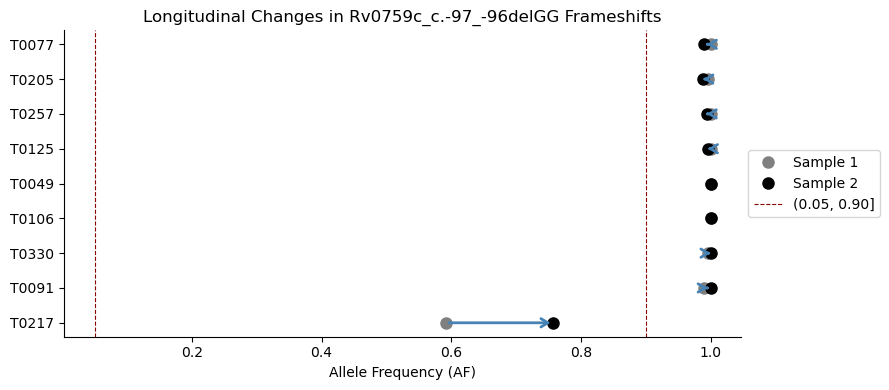

In [149]:
fig, ax = plt.subplots(figsize=(9, 4))

# Loop through samples and draw arrows
for i, row in plot_AF_matrix.iloc[::-1, :].iterrows():
    ax.annotate(
        '', xy=(row['Sample2'], row['pid']), xytext=(row['Sample1'], row['pid']),
        arrowprops=dict(arrowstyle='->,head_length=0.5,head_width=0.3', color='steelblue', lw=2)
    )
    # add point markers for the AFs
    ax.plot(row['Sample1'], row['pid'], 'o', color='gray', zorder=0, markersize=8, label='Sample 1')
    ax.plot(row['Sample2'], row['pid'], 'o', color='black', zorder=0, markersize=8, label='Sample 2')

# plt.axvline(0.05, color='darkred', linestyle='--', linewidth=0.8, label = '(0.05, 0.90]')
# plt.axvline(0.90, color='darkred', linestyle='--', linewidth=0.8, label = '(0.05, 0.90]')
ax.set_xlabel('Allele Frequency (AF)')
# ax.set_ylabel('Sample')
ax.set_title(f'Longitudinal Changes in {variant} Frameshifts')
# plt.grid(axis='x', linestyle='--', alpha=0.5)
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='center left', bbox_to_anchor=(1, 0.5))
sns.despine()
plt.tight_layout()
plt.show()
# plt.savefig(f"./results/figures/{variant}_within_sample_changes.svg")